In [1]:
import os
import mne
# import PyQt6
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

from collections import Counter

import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, classification_report, f1_score
from sklearn.model_selection import StratifiedKFold

from scipy import stats
from scipy.stats import ttest_rel
from scipy.stats import false_discovery_control

import mne_connectivity
# %matplotlib qt

# Read data

In [2]:
folders = [x for x in os.listdir('OCD/') if os.path.isdir('OCD/' + x)]
fldr2label = {folders[i]: i for i in range(len(folders))}
fldr2label

{'anxiety_ADD (47)': 0,
 'anxiety_AFD (18)': 1,
 'anxiety_general_AD (16)': 2,
 'bipolar_BPD_1(26)': 3,
 'bipolar_BPD_2(25)': 4,
 'controls (157)': 5,
 'Cyclothymia(10)': 6,
 'depression_mild (29)': 7,
 'depression_moderade (47)': 8,
 'depression_severe (32)': 9,
 'personality_disorder (56)': 10,
 'stress_eating_disorder (14)': 11,
 'stress_neurasthenia (7)': 12,
 'stress_Somatoform_disorder (12)': 13,
 'stress_Stress_disorder (24)': 14}

In [3]:
label2class = {
    0: 0, 1: 0, 2: 0, # anxiety
    3: 1, 4: 1, 6: 1, # bipolar
    5: 2, # control
    7: 3, 8: 3, 9: 3, # depression
    10: 4, # personality disorder,
    11: 5, 12: 5, 13: 5, 14: 5# stress
}

class2name = {0: 'anxiety', 1: 'bipolar', 2: 'control', 3: 'depression', 4: 'personality disorder', 5: 'stress'}
name2class = {v: k for k, v in class2name.items()}

In [4]:
og_files = []
zg_files = []
og_labels = []
zg_labels = []
for fldr in folders:
    pth =  'OCD/' + fldr
    og_pths = [x for x in os.listdir(pth) if x.lower().endswith('.edf') and ('og.' in x.lower() or 'ог.' in x.lower() or 'eo.' in x.lower() or '_eo' in x.lower())]
    zg_pths = [x for x in os.listdir(pth) if x.lower().endswith('.edf') and ('zg.' in x.lower() or 'зг.' in x.lower() or 'ec.' in x.lower() or 'fon.' in x.lower() or '_ec' in x.lower() or 'eс.' in x.lower())]
    left = [x for x in os.listdir(pth) if x not in og_pths and x not in zg_pths]
    if len(left) > 0:
        print(pth, left)
    for f in og_pths:
        og_files.append(pth + '/' + f)
        og_labels.append(fldr2label[fldr])
    for f in zg_pths:
        zg_files.append(pth + '/' + f)
        zg_labels.append(fldr2label[fldr])

print(f'Number of files for open eyes: {len(og_files)}')
print(f'Number of files for closed eyes: {len(zg_files)}')

# ensured that og_files[i] is the pair for zg_files[i]

Number of files for open eyes: 518
Number of files for closed eyes: 518


In [5]:
lens = []
for f in tqdm(og_files):
    try:
        sample = mne.io.read_raw_edf(f, verbose=False)
        lens.append(1.0 * len(sample) / sample.info['sfreq'])
    except Exception as e:
        print(f, e)

  0%|          | 0/518 [00:00<?, ?it/s]

OCD/controls (157)/Kutuz_f23_contr_og.edf could not convert string to float: '        '
OCD/controls (157)/Skopincev_20_EO_free.edf could not convert string to float: '        '


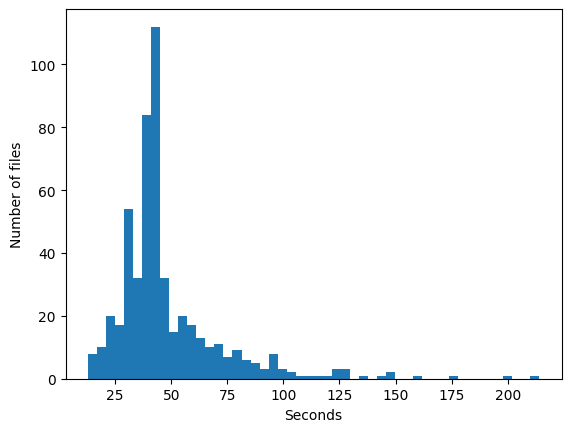

In [6]:
plt.hist(lens, bins=50)
plt.xlabel('Seconds')
plt.ylabel('Number of files')
plt.show()

In [7]:
short_recordings = []
for i in tqdm(range(len(og_files))):
    og_file = og_files[i]
    zg_file = zg_files[i]
    try:
        og_sample = mne.io.read_raw_edf(og_file, verbose=False)
        og_len = 1.0 * len(og_sample) / sample.info['sfreq']
        zg_sample = mne.io.read_raw_edf(zg_file, verbose=False)
        zg_len = 1.0 * len(zg_sample) / zg_sample.info['sfreq']
        if zg_len < 20 or og_len < 20:
            short_recordings.append(i)
    except Exception as e:
        print(f, e)

  0%|          | 0/518 [00:00<?, ?it/s]

OCD/stress_Stress_disorder (24)/МОГУТИНА ВВ_31_F43-0_ОГ.EDF could not convert string to float: '        '
OCD/stress_Stress_disorder (24)/МОГУТИНА ВВ_31_F43-0_ОГ.EDF could not convert string to float: '        '


In [8]:
len(short_recordings)

15

In [9]:
og_files = [x for i, x in enumerate(og_files) if i not in short_recordings]
zg_files = [x for i, x in enumerate(zg_files) if i not in short_recordings]
og_labels = [x for i, x in enumerate(og_labels) if i not in short_recordings]
zg_labels = [x for i, x in enumerate(zg_labels) if i not in short_recordings]

og_no_stress = [x for i, x in enumerate(og_files) if label2class[og_labels[i]] != 5]
zg_no_stress = [x for i, x in enumerate(zg_files) if label2class[zg_labels[i]] != 5]
og_labels_no_stress = [x for i, x in enumerate(og_labels) if label2class[og_labels[i]] != 5]
zg_labels_no_stress = [x for i, x in enumerate(zg_labels) if label2class[zg_labels[i]] != 5]

In [10]:
cnt = Counter([label2class[x] for x in og_labels])
print({class2name[x]: cnt[x] for x in cnt})

{'anxiety': 80, 'bipolar': 59, 'control': 157, 'depression': 102, 'personality disorder': 52, 'stress': 53}


In [11]:
cnt = Counter([label2class[x] for x in og_labels_no_stress])
print({class2name[x]: cnt[x] for x in cnt})

{'anxiety': 80, 'bipolar': 59, 'control': 157, 'depression': 102, 'personality disorder': 52}


# Predict control

In [12]:
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=92)

labels = [label2class[x] for x in og_labels]

f1_scores = []
for i, (train, test) in enumerate(kf.split(list(range(len(labels))), labels)):
    y_test = np.array(labels)[test]
    f1_scores.append(f1_score(y_test, [2 for _ in range(len(y_test))], average='macro'))

print(f'F1 score: {np.mean(f1_scores)}, std: {np.std(f1_scores)}')

F1 score: 0.07929092915031043, std: 0.0010324857010603884


In [13]:
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=92)

labels = [label2class[x] for x in og_labels_no_stress]

f1_scores = []
for i, (train, test) in enumerate(kf.split(list(range(len(labels))), labels)):
    y_test = np.array(labels)[test]
    f1_scores.append(f1_score(y_test, [2 for _ in range(len(y_test))], average='macro'))

print(f'F1 score: {np.mean(f1_scores)}, std: {np.std(f1_scores)}')

F1 score: 0.10345481642053922, std: 0.001194711160279026


# Topography features

In [12]:
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score
from sklearn.svm import SVC

In [13]:
def get_frontal_features(ch_names, psd):
    indices = [i for i in range(len(ch_names)) if 'F3' in ch_names[i] or 'Fz' in ch_names[i] or 'F4' in ch_names[i]]
    return psd[indices]

def get_central_features(ch_names, psd):
    indices = [i for i in range(len(ch_names)) if 'C3' in ch_names[i] or 'Cz' in ch_names[i] or 'C4' in ch_names[i]]
    return psd[indices]

def get_parietal_features(ch_names, psd):
    indices = [i for i in range(len(ch_names)) if 'P3' in ch_names[i] or 'Pz' in ch_names[i] or 'P4' in ch_names[i]]
    return psd[indices]

def get_frontal2central_gradient(ch_names, psd):
    frontal_indices = [i for i in range(len(ch_names)) if 'F3' in ch_names[i] or 'Fz' in ch_names[i] or 'F4' in ch_names[i]]
    central_indices = [i for i in range(len(ch_names)) if 'C3' in ch_names[i] or 'Cz' in ch_names[i] or 'C4' in ch_names[i]]
    return np.sum(psd[frontal_indices], axis=0) / np.sum(psd[central_indices], axis=0)

def get_frontal2parietal_gradient(ch_names, psd):
    frontal_indices = [i for i in range(len(ch_names)) if 'F3' in ch_names[i] or 'Fz' in ch_names[i] or 'F4' in ch_names[i]]
    parietal_indices = [i for i in range(len(ch_names)) if 'P3' in ch_names[i] or 'Pz' in ch_names[i] or 'P4' in ch_names[i]]
    return np.sum(psd[frontal_indices], axis=0) / np.sum(psd[parietal_indices], axis=0)

def get_central2parietal_gradient(ch_names, psd):
    central_indices = [i for i in range(len(ch_names)) if 'C3' in ch_names[i] or 'Cz' in ch_names[i] or 'C4' in ch_names[i]]
    parietal_indices = [i for i in range(len(ch_names)) if 'P3' in ch_names[i] or 'Pz' in ch_names[i] or 'P4' in ch_names[i]]
    return np.sum(psd[central_indices], axis=0) / np.sum(psd[parietal_indices], axis=0)

def get_front2back_gradient(ch_names, psd):
    front_indices = [i for i in range(len(ch_names)) if any([x in ch_names[i] for x in ['Fp1', 'Fp2', 'F3', 'Fz', 'F4']])]  
    back_indices = [i for i in range(len(ch_names)) if any([x in ch_names[i] for x in ['O1', 'O2', 'P3', 'Pz', 'P4']])]
    return np.sum(psd[front_indices], axis=0) / np.sum(psd[back_indices], axis=0)

def get_left2right_gradient(ch_names, psd):
    left_indices = [i for i in range(len(ch_names)) if any([x in ch_names[i] for x in ['F3', 'C3', 'P3', 'O1']])]
    right_indices = [i for i in range(len(ch_names)) if any([x in ch_names[i] for x in ['F4', 'C4', 'P4', 'O2']])]
    return np.sum(psd[left_indices], axis=0) / np.sum(psd[right_indices], axis=0)


## Open eyes

In [64]:
channels2use = ['Fp1', 'Fp2', 'F3', 'Fz', 'F4', 'F7', 'F8', 'T3', 'T4', 'C3', 'Cz', 'C4', 'T5', 'T6', 'P3', 'Pz', 'P4', 'O1', 'O2']
freq_bands = [(6, 8), (8, 10), (10, 12), (12, 14), (13, 20), (20, 26), (8, 13), (13, 26), (8, 26), (6, 26)]

classifiers = {'SVM': SVC(random_state=92), 'KNN': KNeighborsClassifier()}

topo_features_og = []

for i in tqdm(range(len(og_files))):
    path = og_files[i]
    try:
        sample = mne.io.read_raw_edf(path, verbose=False, preload=True)
    except Exception as e:
        print(f'skipped {path}')
        continue
    # skip faulty data for now
    if 'chan' in sample.ch_names[0].lower():
        print(f'skipped {path}')
        continue
    sample = sample.filter(l_freq=1, h_freq=30, method='iir', verbose=False)
    # get only necessary channels, reorder them
    channels = sample.ch_names
    to_drop = channels[19:]
    sample.drop_channels(to_drop)
    new_idx = []
    skip = False
    for ch in channels2use:
        found = False
        for k in range(19):
            if ch in channels[k]:
                new_idx.append(k)
                found = True
                break
        if not found:
            skip = True
            break
    if skip:
        print(f'skipped {path}')
        continue
    
    sample_copy = sample.copy()
    sample_copy = sample_copy.resample(100)
    data = sample_copy.get_data()[:, :int(20 * 100)]
    s_freq = int(100)
    psd, freqs = mne.time_frequency.psd_array_multitaper(data, sfreq=s_freq, fmin=0.5, fmax=30, normalization='length', verbose=False)
    topo_features_og.append({
        'frontal': get_frontal_features(channels, psd),
        'central': get_central_features(channels, psd),
        'parietal': get_parietal_features(channels, psd),
        'frontal2central': get_frontal2central_gradient(channels, psd),
        'frontal2parietal': get_frontal2parietal_gradient(channels, psd),
        'central2parietal': get_central2parietal_gradient(channels, psd),
        'front2back': get_front2back_gradient(channels, psd),
        'left2right': get_left2right_gradient(channels, psd),
        'label': og_labels[i]
    })

    # for k, v in topo_features_og[-1].items():
    #     if k != 'label':
    #         print(k, print(np.array(v).shape))

  0%|          | 0/503 [00:00<?, ?it/s]

skipped OCD/controls (157)/BORUTTO_JANNA_VLADIMIROVNA_48_EO_free.edf
skipped OCD/controls (157)/Kutuz_f23_contr_og.edf
skipped OCD/controls (157)/MANUILOVA_ELENA_55_og.edf
skipped OCD/controls (157)/Martinenko_m45_og.edf
skipped OCD/controls (157)/Skopincev_20_EO_free.edf
skipped OCD/depression_moderade (47)/FiAV_m50_f32-1_At_Nt_og.edf


In [65]:
frontal_features = [x['frontal'] for x in topo_features_og]
central_features = [x['central'] for x in topo_features_og]
parietal_features = [x['parietal'] for x in topo_features_og]
frontal2central_features = [x['frontal2central'] for x in topo_features_og]
frontal2parietal_features = [x['frontal2parietal'] for x in topo_features_og]
central2parietal_features = [x['central2parietal'] for x in topo_features_og]
front2back_features = [x['front2back'] for x in topo_features_og]
left2right_features = [x['left2right'] for x in topo_features_og]
labels = [label2class[x['label']] for x in topo_features_og]

### Features one by one

In [105]:
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=92)

for k in topo_features_og[0].keys():
    if k == 'label':
        continue
    f1_scores = []
    print(k)
    features = [x[k].flatten() for x in topo_features_og]
    for i, (train, test) in enumerate(kf.split(list(range(len(labels))), labels)):
        clf = KNeighborsClassifier(weights='distance')
        X_train = np.array(features)[train]
        X_test = np.array(features)[test]
        y_train = np.array(labels)[train]
        y_test = np.array(labels)[test]
        clf.fit(X_train, y_train)   
        f1_scores.append(f1_score(y_test, clf.predict(X_test), average='macro'))

    print(f'\tF1 score: {np.mean(f1_scores)}, std: {np.std(f1_scores)}')

frontal
	F1 score: 0.35663265600692085, std: 0.029449901668746923
central
	F1 score: 0.3307836874062967, std: 0.04411119626962629
parietal
	F1 score: 0.351883378743824, std: 0.043596380212754
frontal2central
	F1 score: 0.30632022778146906, std: 0.028600623972279866
frontal2parietal
	F1 score: 0.2937168624431178, std: 0.022917042420985592
central2parietal
	F1 score: 0.2856539720555024, std: 0.04747600794153626
front2back
	F1 score: 0.2942985138462336, std: 0.030530101465956562
left2right
	F1 score: 0.30203031459300794, std: 0.027550922889546393


In [19]:
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=92)

for k in topo_features_og[0].keys():
    if k == 'label':
        continue
    f1_scores = []
    print(k)
    features = [x[k].flatten() for x in topo_features_og]
    for i, (train, test) in enumerate(kf.split(list(range(len(labels))), labels)):
        clf = SVC(kernel='rbf', random_state=92)
        X_train = np.array(features)[train]
        X_test = np.array(features)[test]
        y_train = np.array(labels)[train]
        y_test = np.array(labels)[test]
        clf.fit(X_train, y_train)   
        f1_scores.append(f1_score(y_test, clf.predict(X_test), average='macro'))

    print(f'\tF1 score: {np.mean(f1_scores)}, std: {np.std(f1_scores)}')

frontal
	F1 score: 0.16555323795494803, std: 0.018874412177220697
central
	F1 score: 0.18909549059988545, std: 0.037723603970902415
parietal
	F1 score: 0.17231383336692108, std: 0.032417959028559845
frontal2central
	F1 score: 0.1530682402623879, std: 0.047977915833603176
frontal2parietal
	F1 score: 0.20462911426382685, std: 0.04587552681544575
central2parietal
	F1 score: 0.2305733966097089, std: 0.040798813273076044
front2back
	F1 score: 0.17107984022023248, std: 0.022918451379671016
left2right
	F1 score: 0.19501713123082123, std: 0.01872112611975724


Stress removed

In [20]:
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=92)

new_ids = [i for i in range(len(labels)) if labels[i] != 5]
new_labels = [labels[i] for i in new_ids]

for k in topo_features_og[0].keys():
    if k == 'label':
        continue
    f1_scores = []
    print(k)
    features = [topo_features_og[i][k].flatten() for i in new_ids]
    for i, (train, test) in enumerate(kf.split(list(range(len(new_labels))), new_labels)):
        clf = KNeighborsClassifier()
        X_train = np.array(features)[train]
        X_test = np.array(features)[test]
        y_train = np.array(new_labels)[train]
        y_test = np.array(new_labels)[test]
        clf.fit(X_train, y_train)   
        f1_scores.append(f1_score(y_test, clf.predict(X_test), average='macro'))

    print(f'\tF1 score: {np.mean(f1_scores)}, std: {np.std(f1_scores)}')

frontal
	F1 score: 0.29305527361620476, std: 0.04324616249854776
central
	F1 score: 0.3039314524688027, std: 0.0456547929694156
parietal
	F1 score: 0.3136887928300248, std: 0.050838472424890035
frontal2central
	F1 score: 0.28616910752496544, std: 0.05044514652085816
frontal2parietal
	F1 score: 0.25049544327474715, std: 0.04608560952278569
central2parietal
	F1 score: 0.257467631070972, std: 0.023826890612207614
front2back
	F1 score: 0.24090978898877516, std: 0.03092212441182581
left2right
	F1 score: 0.23715028164060423, std: 0.016756001682152865


In [21]:
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=92)

new_ids = [i for i in range(len(labels)) if labels[i] != 5]
new_labels = [labels[i] for i in new_ids]

for k in topo_features_og[0].keys():
    if k == 'label':
        continue
    f1_scores = []
    print(k)
    features = [topo_features_og[i][k].flatten() for i in new_ids]
    for i, (train, test) in enumerate(kf.split(list(range(len(new_labels))), new_labels)):
        clf = SVC(kernel='rbf', random_state=92)
        X_train = np.array(features)[train]
        X_test = np.array(features)[test]
        y_train = np.array(new_labels)[train]
        y_test = np.array(new_labels)[test]
        clf.fit(X_train, y_train)   
        f1_scores.append(f1_score(y_test, clf.predict(X_test), average='macro'))

    print(f'\tF1 score: {np.mean(f1_scores)}, std: {np.std(f1_scores)}')

frontal
	F1 score: 0.16592972289732238, std: 0.017196660287799453
central
	F1 score: 0.19040963141641382, std: 0.032507836435190986
parietal
	F1 score: 0.20880419061548214, std: 0.021448895128750103
frontal2central
	F1 score: 0.16589484410742014, std: 0.02793481377250465
frontal2parietal
	F1 score: 0.20225666769567557, std: 0.027542459341851077
central2parietal
	F1 score: 0.24056768393214673, std: 0.03898323549781101
front2back
	F1 score: 0.2074942271851588, std: 0.044528682186476924
left2right
	F1 score: 0.2258914821395741, std: 0.012871209121100112


### All features

In [106]:
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=92)

features = []
for i in range(len(labels)):
    features.append(np.concatenate([topo_features_og[i][k].flatten() for k in topo_features_og[0].keys() if k != 'label']))
f1_scores = []
for i, (train, test) in enumerate(kf.split(list(range(len(labels))), labels)):
    clf = KNeighborsClassifier(weights='distance')
    X_train = np.array(features)[train]
    X_test = np.array(features)[test]
    y_train = np.array(labels)[train]
    y_test = np.array(labels)[test]
    clf.fit(X_train, y_train)   
    f1_scores.append(f1_score(y_test, clf.predict(X_test), average='macro'))

print(f'F1 score: {np.mean(f1_scores)}, std: {np.std(f1_scores)}')

F1 score: 0.33261401664538137, std: 0.029329341199946988


In [23]:
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=92)

features = []
for i in range(len(labels)):
    features.append(np.concatenate([topo_features_og[i][k].flatten() for k in topo_features_og[0].keys() if k != 'label']))
f1_scores = []
for i, (train, test) in enumerate(kf.split(list(range(len(labels))), labels)):
    clf = SVC(kernel='linear', random_state=92)
    X_train = np.array(features)[train]
    X_test = np.array(features)[test]
    y_train = np.array(labels)[train]
    y_test = np.array(labels)[test]
    clf.fit(X_train, y_train)   
    f1_scores.append(f1_score(y_test, clf.predict(X_test), average='macro'))

print(f'F1 score: {np.mean(f1_scores)}, std: {np.std(f1_scores)}')

F1 score: 0.303274981921586, std: 0.040090227409912964


In [38]:
# no stress
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=92)

new_ids = [i for i in range(len(labels)) if labels[i] != 5]
new_labels = [labels[i] for i in new_ids]

features = []
for i in new_ids:
    features.append(np.concatenate([topo_features_og[i][k].flatten() for k in topo_features_og[0].keys() if k != 'label']))
f1_scores = []
for i, (train, test) in enumerate(kf.split(list(range(len(new_labels))), new_labels)):
    clf = SVC(kernel='linear', random_state=92)
    X_train = np.array(features)[train]
    X_test = np.array(features)[test]
    y_train = np.array(labels)[train]
    y_test = np.array(labels)[test]
    clf.fit(X_train, y_train)   
    f1_scores.append(f1_score(y_test, clf.predict(X_test), average='macro'))

print(f'F1 score: {np.mean(f1_scores)}, std: {np.std(f1_scores)}')

F1 score: 0.31844771239950276, std: 0.04473834657533119


In [112]:
# removing any gives no improvement
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=92)

features = []
for i in range(len(labels)):
    features.append(np.concatenate([topo_features_og[i][k].flatten() for k in ['frontal', 'parietal']]))
f1_scores = []
for i, (train, test) in enumerate(kf.split(list(range(len(labels))), labels)):
    clf = KNeighborsClassifier(weights='distance')
    X_train = np.array(features)[train]
    X_test = np.array(features)[test]
    y_train = np.array(labels)[train]
    y_test = np.array(labels)[test]
    clf.fit(X_train, y_train)   
    f1_scores.append(f1_score(y_test, clf.predict(X_test), average='macro'))

print(f'F1 score: {np.mean(f1_scores)}, std: {np.std(f1_scores)}')

F1 score: 0.3755382749634525, std: 0.047795461404712476


In [39]:
# no stress
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=92)

new_ids = [i for i in range(len(labels)) if labels[i] != 5]
new_labels = [labels[i] for i in new_ids]

features = []
for i in new_ids:
    features.append(np.concatenate([topo_features_og[i][k].flatten() for k in ['frontal', 'central', 'parietal']]))
f1_scores = []
for i, (train, test) in enumerate(kf.split(list(range(len(new_labels))), new_labels)):
    clf = KNeighborsClassifier()
    X_train = np.array(features)[train]
    X_test = np.array(features)[test]
    y_train = np.array(labels)[train]
    y_test = np.array(labels)[test]
    clf.fit(X_train, y_train)   
    f1_scores.append(f1_score(y_test, clf.predict(X_test), average='macro'))

print(f'F1 score: {np.mean(f1_scores)}, std: {np.std(f1_scores)}')

F1 score: 0.3311246940858261, std: 0.05777273640667664


In [49]:
# removing any gives no improvement
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=92)

features = []
for i in range(len(labels)):
    features.append(np.concatenate([topo_features_og[i][k].flatten() for k in ['frontal', 'central', 'parietal']]))
f1_scores = []
for i, (train, test) in enumerate(kf.split(list(range(len(labels))), labels)):
    clf = SVC(kernel='rbf', random_state=92)
    X_train = np.array(features)[train]
    X_test = np.array(features)[test]
    y_train = np.array(labels)[train]
    y_test = np.array(labels)[test]
    clf.fit(X_train, y_train)   
    f1_scores.append(f1_score(y_test, clf.predict(X_test), average='macro'))

print(f'F1 score: {np.mean(f1_scores)}, std: {np.std(f1_scores)}')

F1 score: 0.16489680971377024, std: 0.01705254296719352


In [116]:
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=92)

features = []
for i in range(len(labels)):
    features.append(np.concatenate([topo_features_og[i][k].flatten() for k in ['frontal2central', 'central2parietal']]))
f1_scores = []
for i, (train, test) in enumerate(kf.split(list(range(len(labels))), labels)):
    clf = KNeighborsClassifier(weights='distance')
    X_train = np.array(features)[train]
    X_test = np.array(features)[test]
    y_train = np.array(labels)[train]
    y_test = np.array(labels)[test]
    clf.fit(X_train, y_train)   
    f1_scores.append(f1_score(y_test, clf.predict(X_test), average='macro'))

print(f'F1 score: {np.mean(f1_scores)}, std: {np.std(f1_scores)}')

F1 score: 0.310949340625834, std: 0.032675593952283005


In [ ]:
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=92)

features = []
for i in range(len(labels)):
    features.append(np.concatenate([topo_features_og[i][k].flatten() for k in ['frontal2central', 'frontal2parietal', 'central2parietal']]))
f1_scores = []
for i, (train, test) in enumerate(kf.split(list(range(len(labels))), labels)):
    clf = SVC(kernel='linear', random_state=92)
    X_train = np.array(features)[train]
    X_test = np.array(features)[test]
    y_train = np.array(labels)[train]
    y_test = np.array(labels)[test]
    clf.fit(X_train, y_train)   
    f1_scores.append(f1_score(y_test, clf.predict(X_test), average='macro'))

print(f'F1 score: {np.mean(f1_scores)}, std: {np.std(f1_scores)}')

F1 score: 0.26489862023368654, std: 0.06414953967064445


In [40]:
# no stress
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=92)

new_ids = [i for i in range(len(labels)) if labels[i] != 5]
new_labels = [labels[i] for i in new_ids]

features = []
for i in new_ids:
    features.append(np.concatenate([topo_features_og[i][k].flatten() for k in ['frontal2central', 'frontal2parietal', 'central2parietal']]))
f1_scores = []
for i, (train, test) in enumerate(kf.split(list(range(len(new_labels))), new_labels)):
    clf = SVC(kernel='linear', random_state=92)
    X_train = np.array(features)[train]
    X_test = np.array(features)[test]
    y_train = np.array(labels)[train]
    y_test = np.array(labels)[test]
    clf.fit(X_train, y_train)   
    f1_scores.append(f1_score(y_test, clf.predict(X_test), average='macro'))

print(f'F1 score: {np.mean(f1_scores)}, std: {np.std(f1_scores)}')

F1 score: 0.26347597574119663, std: 0.05760461831763478


In [59]:
# gives no improvement
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=92)

features = []
for i in range(len(labels)):
    features.append(np.concatenate([topo_features_og[i][k].flatten() for k in ['frontal', 'central', 'frontal2parietal']]))
f1_scores = []
for i, (train, test) in enumerate(kf.split(list(range(len(labels))), labels)):
    clf = KNeighborsClassifier()
    X_train = np.array(features)[train]
    X_test = np.array(features)[test]
    y_train = np.array(labels)[train]
    y_test = np.array(labels)[test]
    clf.fit(X_train, y_train)   
    f1_scores.append(f1_score(y_test, clf.predict(X_test), average='macro'))

print(f'F1 score: {np.mean(f1_scores)}, std: {np.std(f1_scores)}')

F1 score: 0.1890295122410804, std: 0.02506733638747598


In [117]:
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=92)

features = []
for i in range(len(labels)):
    features.append(np.concatenate([topo_features_og[i][k].flatten() for k in ['front2back', 'left2right']]))
f1_scores = []
for i, (train, test) in enumerate(kf.split(list(range(len(labels))), labels)):
    clf = KNeighborsClassifier(weights='distance')
    X_train = np.array(features)[train]
    X_test = np.array(features)[test]
    y_train = np.array(labels)[train]
    y_test = np.array(labels)[test]
    clf.fit(X_train, y_train)   
    f1_scores.append(f1_score(y_test, clf.predict(X_test), average='macro'))

print(f'F1 score: {np.mean(f1_scores)}, std: {np.std(f1_scores)}')

F1 score: 0.3091628673211363, std: 0.010278886991709037


In [31]:
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=92)

features = []
for i in range(len(labels)):
    features.append(np.concatenate([topo_features_og[i][k].flatten() for k in ['front2back', 'left2right']]))
f1_scores = []
for i, (train, test) in enumerate(kf.split(list(range(len(labels))), labels)):
    clf = SVC(kernel='linear', random_state=92)
    X_train = np.array(features)[train]
    X_test = np.array(features)[test]
    y_train = np.array(labels)[train]
    y_test = np.array(labels)[test]
    clf.fit(X_train, y_train)   
    f1_scores.append(f1_score(y_test, clf.predict(X_test), average='macro'))

print(f'F1 score: {np.mean(f1_scores)}, std: {np.std(f1_scores)}')

F1 score: 0.3247356927150109, std: 0.032323657724301944


In [33]:
# gives no improvement
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=92)

features = []
for i in range(len(labels)):
    features.append(np.concatenate([topo_features_og[i][k].flatten() for k in ['front2back', 'left2right', 'frontal', 'central', 'parietal']]))
f1_scores = []
for i, (train, test) in enumerate(kf.split(list(range(len(labels))), labels)):
    clf = SVC(kernel='linear', random_state=92)
    X_train = np.array(features)[train]
    X_test = np.array(features)[test]
    y_train = np.array(labels)[train]
    y_test = np.array(labels)[test]
    clf.fit(X_train, y_train)   
    f1_scores.append(f1_score(y_test, clf.predict(X_test), average='macro'))

print(f'F1 score: {np.mean(f1_scores)}, std: {np.std(f1_scores)}')

F1 score: 0.3247356927150109, std: 0.032323657724301944


In [34]:
# 'frontal2central', 'frontal2parietal', 'central2parietal'
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=92)

features = []
for i in range(len(labels)):
    features.append(np.concatenate([topo_features_og[i][k].flatten() for k in ['front2back', 'left2right', 'frontal2parietal']]))
f1_scores = []
for i, (train, test) in enumerate(kf.split(list(range(len(labels))), labels)):
    clf = SVC(kernel='linear', random_state=92)
    X_train = np.array(features)[train]
    X_test = np.array(features)[test]
    y_train = np.array(labels)[train]
    y_test = np.array(labels)[test]
    clf.fit(X_train, y_train)   
    f1_scores.append(f1_score(y_test, clf.predict(X_test), average='macro'))

print(f'F1 score: {np.mean(f1_scores)}, std: {np.std(f1_scores)}')

F1 score: 0.31458985503703407, std: 0.05138710795066844


### Best configuration

In [122]:
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=92)

features = []
for i in range(len(labels)):
    features.append(np.concatenate([topo_features_og[i][k].flatten() for k in ['frontal', 'parietal']]))
f1_scores = []
for i, (train, test) in enumerate(kf.split(list(range(len(labels))), labels)):
    clf = KNeighborsClassifier(weights='distance')
    X_train = np.array(features)[train]
    X_test = np.array(features)[test]
    y_train = np.array(labels)[train]
    y_test = np.array(labels)[test]
    clf.fit(X_train, y_train)   
    f1_scores.append(f1_score(y_test, clf.predict(X_test), average='macro'))

print(f'F1 score: {np.mean(f1_scores)}, std: {np.std(f1_scores)}')

F1 score: 0.3755382749634525, std: 0.047795461404712476


In [37]:
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=92)

features = []
for i in range(len(labels)):
    features.append(np.concatenate([topo_features_og[i][k].flatten() for k in ['front2back', 'left2right']]))
f1_scores = []
for i, (train, test) in enumerate(kf.split(list(range(len(labels))), labels)):
    clf = SVC(kernel='linear', random_state=92)
    X_train = np.array(features)[train]
    X_test = np.array(features)[test]
    y_train = np.array(labels)[train]
    y_test = np.array(labels)[test]
    clf.fit(X_train, y_train)   
    f1_scores.append(f1_score(y_test, clf.predict(X_test), average='macro'))

print(f'F1 score: {np.mean(f1_scores)}, std: {np.std(f1_scores)}')

IndexError: list index out of range

In [36]:
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=92)

new_ids = [i for i in range(len(labels)) if labels[i] != 5]
new_labels = [labels[i] for i in new_ids]

features = []
for i in new_ids:
    features.append(np.concatenate([topo_features_og[i][k].flatten() for k in ['front2back', 'left2right']]))
f1_scores = []
for i, (train, test) in enumerate(kf.split(list(range(len(new_labels))), new_labels)):
    clf = SVC(kernel='linear', random_state=92)
    X_train = np.array(features)[train]
    X_test = np.array(features)[test]
    y_train = np.array(labels)[train]
    y_test = np.array(labels)[test]
    clf.fit(X_train, y_train)   
    f1_scores.append(f1_score(y_test, clf.predict(X_test), average='macro'))

print(f'F1 score: {np.mean(f1_scores)}, std: {np.std(f1_scores)}')

F1 score: 0.326742029185478, std: 0.04628009291321324


## Closed eyes

In [76]:
channels2use = ['Fp1', 'Fp2', 'F3', 'Fz', 'F4', 'F7', 'F8', 'T3', 'T4', 'C3', 'Cz', 'C4', 'T5', 'T6', 'P3', 'Pz', 'P4', 'O1', 'O2']
freq_bands = [(6, 8), (8, 10), (10, 12), (12, 14), (13, 20), (20, 26), (8, 13), (13, 26), (8, 26), (6, 26)]

classifiers = {'SVM': SVC(random_state=92), 'KNN': KNeighborsClassifier()}

topo_features_zg = []

to_skip = ['BORUTTO_JANNA_VLADIMIROVNA', 'Kutuz_f23_contr', 'MANUILOVA_ELENA_55', 'Martinenko_m45', 'Skopincev_20', 'FiAV_m50']

for i in tqdm(range(len(zg_files))):
    path = zg_files[i]
    if any([x in path for x in to_skip]):
        continue
    try:
        sample = mne.io.read_raw_edf(path, verbose=False, preload=True)
    except Exception as e:
        print(f'skipped {path}')
        continue
    # skip faulty data for now
    if 'chan' in sample.ch_names[0].lower():
        print(f'skipped {path}')
        continue
    sample = sample.filter(l_freq=1, h_freq=30, method='iir', verbose=False)
    # get only necessary channels, reorder them
    channels = sample.ch_names
    to_drop = channels[19:]
    sample.drop_channels(to_drop)
    new_idx = []
    skip = False
    for ch in channels2use:
        found = False
        for k in range(19):
            if ch in channels[k]:
                new_idx.append(k)
                found = True
                break
        if not found:
            skip = True
            break
    if skip:
        print(f'skipped {path}')
        continue
    
    sample_copy = sample.copy()
    sample_copy = sample_copy.resample(100)
    data = sample_copy.get_data()[:, :int(20 * 100)]
    s_freq = int(100)
    psd, freqs = mne.time_frequency.psd_array_multitaper(data, sfreq=s_freq, fmin=0.5, fmax=30, normalization='length', verbose=False)
    topo_features_zg.append({
        'frontal': get_frontal_features(channels, psd),
        'central': get_central_features(channels, psd),
        'parietal': get_parietal_features(channels, psd),
        'frontal2central': get_frontal2central_gradient(channels, psd),
        'frontal2parietal': get_frontal2parietal_gradient(channels, psd),
        'central2parietal': get_central2parietal_gradient(channels, psd),
        'front2back': get_front2back_gradient(channels, psd),
        'left2right': get_left2right_gradient(channels, psd),
        'label': zg_labels[i]
    })

  0%|          | 0/503 [00:00<?, ?it/s]

In [77]:
frontal_features = [x['frontal'] for x in topo_features_zg]
central_features = [x['central'] for x in topo_features_zg]
parietal_features = [x['parietal'] for x in topo_features_zg]
frontal2central_features = [x['frontal2central'] for x in topo_features_zg]
frontal2parietal_features = [x['frontal2parietal'] for x in topo_features_zg]
central2parietal_features = [x['central2parietal'] for x in topo_features_zg]
front2back_features = [x['front2back'] for x in topo_features_zg]
left2right_features = [x['left2right'] for x in topo_features_zg]
labels = [label2class[x['label']] for x in topo_features_zg]

### Features one by one

In [123]:
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=92)

for k in topo_features_zg[0].keys():
    if k == 'label':
        continue
    f1_scores = []
    print(k)
    features = [x[k].flatten() for x in topo_features_zg]
    for i, (train, test) in enumerate(kf.split(list(range(len(labels))), labels)):
        clf = KNeighborsClassifier(weights='distance')
        X_train = np.array(features)[train]
        X_test = np.array(features)[test]
        y_train = np.array(labels)[train]
        y_test = np.array(labels)[test]
        clf.fit(X_train, y_train)   
        f1_scores.append(f1_score(y_test, clf.predict(X_test), average='macro'))

    print(f'\tF1 score: {np.mean(f1_scores)}, std: {np.std(f1_scores)}')

frontal
	F1 score: 0.3502500381633823, std: 0.06198612039135716
central
	F1 score: 0.3535353483830857, std: 0.0392567343994322
parietal
	F1 score: 0.34018794159745314, std: 0.03405199720403413
frontal2central
	F1 score: 0.2785496657287616, std: 0.04549722980678359
frontal2parietal
	F1 score: 0.3026378503142261, std: 0.022905952988055117
central2parietal
	F1 score: 0.2551767627468592, std: 0.021915954870880962
front2back
	F1 score: 0.30655565691625064, std: 0.031765314096501934
left2right
	F1 score: 0.2733376004066471, std: 0.04979132105600167


In [ ]:
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=92)

for k in topo_features_zg[0].keys():
    if k == 'label':
        continue
    f1_scores = []
    print(k)
    features = [x[k].flatten() for x in topo_features_zg]
    for i, (train, test) in enumerate(kf.split(list(range(len(labels))), labels)):
        clf = KNeighborsClassifier()
        means_train = np.array(features)[train].mean(axis=0)
        stds_train = np.array(features)[train].std(axis=0)
        X_train = np.array(features)[train]
        X_test = np.array(features)[test]
        y_train = np.array(labels)[train]
        y_test = np.array(labels)[test]
        clf.fit(X_train, y_train)   
        f1_scores.append(f1_score(y_test, clf.predict(X_test), average='macro'))

    print(f'\tF1 score: {np.mean(f1_scores)}, std: {np.std(f1_scores)}')

In [79]:
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=92)

for k in topo_features_zg[0].keys():
    if k == 'label':
        continue
    f1_scores = []
    print(k)
    features = [x[k].flatten() for x in topo_features_zg]
    for i, (train, test) in enumerate(kf.split(list(range(len(labels))), labels)):
        clf = SVC(kernel='linear', random_state=92)
        X_train = np.array(features)[train]
        X_test = np.array(features)[test]
        y_train = np.array(labels)[train]
        y_test = np.array(labels)[test]
        clf.fit(X_train, y_train)   
        f1_scores.append(f1_score(y_test, clf.predict(X_test), average='macro'))

    print(f'\tF1 score: {np.mean(f1_scores)}, std: {np.std(f1_scores)}')

frontal
	F1 score: 0.07806588464497216, std: 0.0009577964690403756
central
	F1 score: 0.07806588464497216, std: 0.0009577964690403756
parietal
	F1 score: 0.07806588464497216, std: 0.0009577964690403756
frontal2central
	F1 score: 0.22584677551801882, std: 0.04034508971034952
frontal2parietal
	F1 score: 0.2829816755486334, std: 0.03900497124288266
central2parietal
	F1 score: 0.2634395339947418, std: 0.02336055156959728
front2back
	F1 score: 0.2594129438949858, std: 0.0353943893714368
left2right
	F1 score: 0.264263755397731, std: 0.03443584529950428


In [80]:
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=92)

for k in topo_features_zg[0].keys():
    if k == 'label':
        continue
    f1_scores = []
    print(k)
    features = [x[k].flatten() for x in topo_features_zg]
    for i, (train, test) in enumerate(kf.split(list(range(len(labels))), labels)):
        clf = SVC(kernel='rbf', random_state=92)
        X_train = np.array(features)[train]
        X_test = np.array(features)[test]
        y_train = np.array(labels)[train]
        y_test = np.array(labels)[test]
        clf.fit(X_train, y_train)   
        f1_scores.append(f1_score(y_test, clf.predict(X_test), average='macro'))

    print(f'\tF1 score: {np.mean(f1_scores)}, std: {np.std(f1_scores)}')

frontal
	F1 score: 0.22346837246809978, std: 0.034501964318375745
central
	F1 score: 0.20185168163320114, std: 0.0356266800249468
parietal
	F1 score: 0.10686287098473432, std: 0.017610689803917015
frontal2central
	F1 score: 0.1927707217923638, std: 0.014943875361460059
frontal2parietal
	F1 score: 0.1713699516347159, std: 0.019002624972448184
central2parietal
	F1 score: 0.1952987202024429, std: 0.0244350832044811
front2back
	F1 score: 0.14556849225119392, std: 0.015494687795621565
left2right
	F1 score: 0.16294914594748805, std: 0.02338113463415623


Stress removed

In [46]:
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=92)

new_ids = [i for i in range(len(labels)) if labels[i]  != 5]
new_labels = [labels[i] for i in new_ids]

for k in topo_features_zg[0].keys():
    if k == 'label':
        continue
    f1_scores = []
    print(k)
    features = [topo_features_zg[i][k].flatten() for i in new_ids]
    for i, (train, test) in enumerate(kf.split(list(range(len(new_labels))), new_labels)):
        clf = KNeighborsClassifier()
        X_train = np.array(features)[train]
        X_test = np.array(features)[test]
        y_train = np.array(new_labels)[train]
        y_test = np.array(new_labels)[test]
        clf.fit(X_train, y_train)   
        f1_scores.append(f1_score(y_test, clf.predict(X_test), average='macro'))

    print(f'\tF1 score: {np.mean(f1_scores)}, std: {np.std(f1_scores)}')

frontal
	F1 score: 0.3189411328554477, std: 0.03537323148886046
central
	F1 score: 0.35772206351274305, std: 0.049133515353522526
parietal
	F1 score: 0.2773399694223493, std: 0.03430566447303074
frontal2central
	F1 score: 0.2242899130213812, std: 0.03945105075599789
frontal2parietal
	F1 score: 0.2504860718591592, std: 0.031166791744000263
central2parietal
	F1 score: 0.2358964652646766, std: 0.028451259292635377
front2back
	F1 score: 0.24027404216368892, std: 0.07005078058322112
left2right
	F1 score: 0.22964800697173357, std: 0.049125170261333784


In [47]:
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=92)

new_ids = [i for i in range(len(labels)) if labels[i]  != 5]
new_labels = [labels[i] for i in new_ids]

for k in topo_features_zg[0].keys():
    if k == 'label':
        continue
    f1_scores = []
    print(k)
    features = [topo_features_zg[i][k].flatten() for i in new_ids]
    for i, (train, test) in enumerate(kf.split(list(range(len(new_labels))), new_labels)):
        clf = SVC(kernel='linear', random_state=92)
        X_train = np.array(features)[train]
        X_test = np.array(features)[test]
        y_train = np.array(new_labels)[train]
        y_test = np.array(new_labels)[test]
        clf.fit(X_train, y_train)   
        f1_scores.append(f1_score(y_test, clf.predict(X_test), average='macro'))

    print(f'\tF1 score: {np.mean(f1_scores)}, std: {np.std(f1_scores)}')

frontal
	F1 score: 0.10201120448179271, std: 0.001460069087510578
central
	F1 score: 0.10201120448179271, std: 0.001460069087510578
parietal
	F1 score: 0.10201120448179271, std: 0.001460069087510578
frontal2central
	F1 score: 0.27694660075041655, std: 0.03647444350553145
frontal2parietal
	F1 score: 0.2621819154200941, std: 0.036695107808839784
central2parietal
	F1 score: 0.2676592642715781, std: 0.03957592431443418
front2back
	F1 score: 0.25915153391341395, std: 0.04049388700250302
left2right
	F1 score: 0.33449274766124304, std: 0.05470875731638111


### All features

In [124]:
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=92)

features = []
for i in range(len(labels)):
    features.append(np.concatenate([topo_features_zg[i][k].flatten() for k in topo_features_zg[0].keys() if k != 'label']))
f1_scores = []
for i, (train, test) in enumerate(kf.split(list(range(len(labels))), labels)):
    clf = KNeighborsClassifier(weights='distance')
    X_train = np.array(features)[train]
    X_test = np.array(features)[test]
    y_train = np.array(labels)[train]
    y_test = np.array(labels)[test]
    clf.fit(X_train, y_train)   
    f1_scores.append(f1_score(y_test, clf.predict(X_test), average='macro'))

print(f'F1 score: {np.mean(f1_scores)}, std: {np.std(f1_scores)}')

F1 score: 0.2908664812875935, std: 0.05242548226869264


In [82]:
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=92)

features = []
for i in range(len(labels)):
    features.append(np.concatenate([topo_features_zg[i][k].flatten() for k in topo_features_zg[0].keys() if k != 'label']))
f1_scores = []
for i, (train, test) in enumerate(kf.split(list(range(len(labels))), labels)):
    clf = SVC(kernel='linear', random_state=92)
    X_train = np.array(features)[train]
    X_test = np.array(features)[test]
    y_train = np.array(labels)[train]
    y_test = np.array(labels)[test]
    clf.fit(X_train, y_train)   
    f1_scores.append(f1_score(y_test, clf.predict(X_test), average='macro'))

print(f'F1 score: {np.mean(f1_scores)}, std: {np.std(f1_scores)}')

F1 score: 0.2859566092838926, std: 0.028653615248199808


In [83]:
# no stress
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=92)

new_ids = [i for i in range(len(labels)) if labels[i]  != 5]
new_labels = [labels[i] for i in new_ids]

features = []
for i in new_ids:
    features.append(np.concatenate([topo_features_zg[i][k].flatten() for k in topo_features_zg[0].keys() if k != 'label']))
f1_scores = []
for i, (train, test) in enumerate(kf.split(list(range(len(new_labels))), new_labels)):
    clf = SVC(kernel='linear', random_state=92)
    X_train = np.array(features)[train]
    X_test = np.array(features)[test]
    y_train = np.array(labels)[train]
    y_test = np.array(labels)[test]
    clf.fit(X_train, y_train)   
    f1_scores.append(f1_score(y_test, clf.predict(X_test), average='macro'))

print(f'F1 score: {np.mean(f1_scores)}, std: {np.std(f1_scores)}')

F1 score: 0.2999484735808841, std: 0.038163312324892895


In [129]:
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=92)

features = []
for i in range(len(labels)):
    features.append(np.concatenate([topo_features_zg[i][k].flatten() for k in ['central', 'parietal']]))
f1_scores = []
for i, (train, test) in enumerate(kf.split(list(range(len(labels))), labels)):
    clf = KNeighborsClassifier(weights='distance')
    X_train = np.array(features)[train]
    X_test = np.array(features)[test]
    y_train = np.array(labels)[train]
    y_test = np.array(labels)[test]
    clf.fit(X_train, y_train)   
    f1_scores.append(f1_score(y_test, clf.predict(X_test), average='macro'))

print(f'F1 score: {np.mean(f1_scores)}, std: {np.std(f1_scores)}')

F1 score: 0.3714425380091561, std: 0.054825511847988624


In [88]:
# no stress
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=92)

new_ids = [i for i in range(len(labels)) if labels[i]  != 5]
new_labels = [labels[i] for i in new_ids]

features = []
for i in new_ids:
    features.append(np.concatenate([topo_features_zg[i][k].flatten() for k in ['frontal', 'central', 'parietal']]))
f1_scores = []
for i, (train, test) in enumerate(kf.split(list(range(len(new_labels))), new_labels)):
    clf = KNeighborsClassifier()
    X_train = np.array(features)[train]
    X_test = np.array(features)[test]
    y_train = np.array(labels)[train]
    y_test = np.array(labels)[test]
    clf.fit(X_train, y_train)   
    f1_scores.append(f1_score(y_test, clf.predict(X_test), average='macro'))

print(f'F1 score: {np.mean(f1_scores)}, std: {np.std(f1_scores)}')

F1 score: 0.2872875460999603, std: 0.03591658830970855


In [89]:
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=92)

features = []
for i in range(len(labels)):
    features.append(np.concatenate([topo_features_zg[i][k].flatten() for k in ['frontal', 'central', 'parietal']]))
f1_scores = []
for i, (train, test) in enumerate(kf.split(list(range(len(labels))), labels)):
    clf = SVC(kernel='linear', random_state=92)
    X_train = np.array(features)[train]
    X_test = np.array(features)[test]
    y_train = np.array(labels)[train]
    y_test = np.array(labels)[test]
    clf.fit(X_train, y_train)   
    f1_scores.append(f1_score(y_test, clf.predict(X_test), average='macro'))

print(f'F1 score: {np.mean(f1_scores)}, std: {np.std(f1_scores)}')

F1 score: 0.07806588464497216, std: 0.0009577964690403756


In [130]:
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=92)

features = []
for i in range(len(labels)):
    features.append(np.concatenate([topo_features_zg[i][k].flatten() for k in ['frontal2central', 'frontal2parietal']]))
f1_scores = []
for i, (train, test) in enumerate(kf.split(list(range(len(labels))), labels)):
    clf = KNeighborsClassifier(weights='distance')
    X_train = np.array(features)[train]
    X_test = np.array(features)[test]
    y_train = np.array(labels)[train]
    y_test = np.array(labels)[test]
    clf.fit(X_train, y_train)   
    f1_scores.append(f1_score(y_test, clf.predict(X_test), average='macro'))

print(f'F1 score: {np.mean(f1_scores)}, std: {np.std(f1_scores)}')

F1 score: 0.2956979781545691, std: 0.018556883556098594


In [97]:
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=92)

features = []
for i in range(len(labels)):
    features.append(np.concatenate([topo_features_zg[i][k].flatten() for k in ['frontal2parietal', 'frontal2central']]))
f1_scores = []
for i, (train, test) in enumerate(kf.split(list(range(len(labels))), labels)):
    clf = SVC(kernel='linear', random_state=92)
    X_train = np.array(features)[train]
    X_test = np.array(features)[test]
    y_train = np.array(labels)[train]
    y_test = np.array(labels)[test]
    clf.fit(X_train, y_train)   
    f1_scores.append(f1_score(y_test, clf.predict(X_test), average='macro'))

print(f'F1 score: {np.mean(f1_scores)}, std: {np.std(f1_scores)}')

F1 score: 0.2801563521174265, std: 0.04217519463697213


In [56]:
# no stress
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=92)

new_ids = [i for i in range(len(labels)) if labels[i]  != 5]
new_labels = [labels[i] for i in new_ids]

features = []
for i in new_ids:
    features.append(np.concatenate([topo_features_zg[i][k].flatten() for k in ['frontal2central', 'frontal2parietal', 'central2parietal']]))
f1_scores = []
for i, (train, test) in enumerate(kf.split(list(range(len(new_labels))), new_labels)):
    clf = SVC(kernel='linear', random_state=92)
    X_train = np.array(features)[train]
    X_test = np.array(features)[test]
    y_train = np.array(labels)[train]
    y_test = np.array(labels)[test]
    clf.fit(X_train, y_train)   
    f1_scores.append(f1_score(y_test, clf.predict(X_test), average='macro'))

print(f'F1 score: {np.mean(f1_scores)}, std: {np.std(f1_scores)}')

F1 score: 0.2699888929534558, std: 0.030885200374211375


In [131]:
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=92)

features = []
for i in range(len(labels)):
    features.append(np.concatenate([topo_features_zg[i][k].flatten() for k in ['front2back', 'left2right']]))
f1_scores = []
for i, (train, test) in enumerate(kf.split(list(range(len(labels))), labels)):
    clf = KNeighborsClassifier(weights='distance')
    X_train = np.array(features)[train]
    X_test = np.array(features)[test]
    y_train = np.array(labels)[train]
    y_test = np.array(labels)[test]
    clf.fit(X_train, y_train)   
    f1_scores.append(f1_score(y_test, clf.predict(X_test), average='macro'))

print(f'F1 score: {np.mean(f1_scores)}, std: {np.std(f1_scores)}')

F1 score: 0.2765254024825654, std: 0.05886428148130822


In [99]:
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=92)

features = []
for i in range(len(labels)):
    features.append(np.concatenate([topo_features_zg[i][k].flatten() for k in ['front2back', 'left2right']]))
f1_scores = []
for i, (train, test) in enumerate(kf.split(list(range(len(labels))), labels)):
    clf = SVC(kernel='linear', random_state=92)
    X_train = np.array(features)[train]
    X_test = np.array(features)[test]
    y_train = np.array(labels)[train]
    y_test = np.array(labels)[test]
    clf.fit(X_train, y_train)   
    f1_scores.append(f1_score(y_test, clf.predict(X_test), average='macro'))

print(f'F1 score: {np.mean(f1_scores)}, std: {np.std(f1_scores)}')

F1 score: 0.2878346875951193, std: 0.035163776198044325


In [60]:
# no stress
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=92)

new_ids = [i for i in range(len(labels)) if labels[i]  != 5]
new_labels = [labels[i] for i in new_ids]

features = []
for i in new_ids:
    features.append(np.concatenate([topo_features_zg[i][k].flatten() for k in ['front2back', 'left2right']]))
f1_scores = []
for i, (train, test) in enumerate(kf.split(list(range(len(new_labels))), new_labels)):
    clf = SVC(kernel='linear', random_state=92)
    X_train = np.array(features)[train]
    X_test = np.array(features)[test]
    y_train = np.array(labels)[train]
    y_test = np.array(labels)[test]
    clf.fit(X_train, y_train)   
    f1_scores.append(f1_score(y_test, clf.predict(X_test), average='macro'))

print(f'F1 score: {np.mean(f1_scores)}, std: {np.std(f1_scores)}')

F1 score: 0.3149140650416262, std: 0.05972826432164317


In [61]:
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=92)

features = []
for i in range(len(labels)):
    features.append(np.concatenate([topo_features_zg[i][k].flatten() for k in ['front2back', 'left2right', 'frontal2parietal']]))
f1_scores = []
for i, (train, test) in enumerate(kf.split(list(range(len(labels))), labels)):
    clf = SVC(kernel='linear', random_state=92)
    X_train = np.array(features)[train]
    X_test = np.array(features)[test]
    y_train = np.array(labels)[train]
    y_test = np.array(labels)[test]
    clf.fit(X_train, y_train)   
    f1_scores.append(f1_score(y_test, clf.predict(X_test), average='macro'))

print(f'F1 score: {np.mean(f1_scores)}, std: {np.std(f1_scores)}')

F1 score: 0.3252767102652494, std: 0.04197844215717606


### Best configuration

In [100]:
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=92)

features = []
for i in range(len(labels)):
    features.append(np.concatenate([topo_features_zg[i][k].flatten() for k in ['front2back', 'left2right', 'frontal2parietal']]))
f1_scores = []
for i, (train, test) in enumerate(kf.split(list(range(len(labels))), labels)):
    clf = SVC(kernel='linear', random_state=92)
    X_train = np.array(features)[train]
    X_test = np.array(features)[test]
    y_train = np.array(labels)[train]
    y_test = np.array(labels)[test]
    clf.fit(X_train, y_train)   
    f1_scores.append(f1_score(y_test, clf.predict(X_test), average='macro'))

print(f'F1 score: {np.mean(f1_scores)}, std: {np.std(f1_scores)}')

F1 score: 0.2977836119963289, std: 0.02971366390826783


In [132]:
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=92)

features = []
for i in range(len(labels)):
    features.append(np.concatenate([topo_features_zg[i][k].flatten() for k in ['central', 'parietal']]))
f1_scores = []
for i, (train, test) in enumerate(kf.split(list(range(len(labels))), labels)):
    clf = KNeighborsClassifier(weights='distance')
    X_train = np.array(features)[train]
    X_test = np.array(features)[test]
    y_train = np.array(labels)[train]
    y_test = np.array(labels)[test]
    clf.fit(X_train, y_train)   
    f1_scores.append(f1_score(y_test, clf.predict(X_test), average='macro'))

print(f'F1 score: {np.mean(f1_scores)}, std: {np.std(f1_scores)}')

F1 score: 0.3714425380091561, std: 0.054825511847988624


In [63]:
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=92)

new_ids = [i for i in range(len(labels)) if labels[i] != 5]
new_labels = [labels[i] for i in new_ids]

features = []
for i in new_ids:
    features.append(np.concatenate([topo_features_zg[i][k].flatten() for k in ['front2back', 'left2right', 'frontal2parietal']]))
f1_scores = []
for i, (train, test) in enumerate(kf.split(list(range(len(new_labels))), new_labels)):
    clf = SVC(kernel='linear', random_state=92)
    X_train = np.array(features)[train]
    X_test = np.array(features)[test]
    y_train = np.array(labels)[train]
    y_test = np.array(labels)[test]
    clf.fit(X_train, y_train)   
    f1_scores.append(f1_score(y_test, clf.predict(X_test), average='macro'))

print(f'F1 score: {np.mean(f1_scores)}, std: {np.std(f1_scores)}')

F1 score: 0.3480605883676261, std: 0.04449374234338924


## Silly experiment for frequency bands selection

Use the best configuration: SVM, with `['central', 'parietal']` features, calculate them in the frequency bands and assess the classification quality

### Open eyes

In [148]:
channels2use = ['Fp1', 'Fp2', 'F3', 'Fz', 'F4', 'F7', 'F8', 'T3', 'T4', 'C3', 'Cz', 'C4', 'T5', 'T6', 'P3', 'Pz', 'P4', 'O1', 'O2']
freq_bands = [(6, 8), (8, 10), (10, 12), (12, 14), (13, 20), (20, 26), (8, 13), (13, 26), (8, 26), (6, 26)]

classifiers = {'SVM': SVC(random_state=92), 'KNN': KNeighborsClassifier(weights='distance')}

band2features = {fb: [] for fb in freq_bands}

for i in tqdm(range(len(og_files))):
    path = og_files[i]
    try:
        sample = mne.io.read_raw_edf(path, verbose=False, preload=True)
    except Exception as e:
        print(f'skipped {path}')
        continue
    # skip faulty data for now
    if 'chan' in sample.ch_names[0].lower():
        print(f'skipped {path}')
        continue
    sample = sample.filter(l_freq=1, h_freq=30, method='iir', verbose=False)
    # get only necessary channels, reorder them
    channels = sample.ch_names
    to_drop = channels[19:]
    sample.drop_channels(to_drop)
    new_idx = []
    skip = False
    for ch in channels2use:
        found = False
        for k in range(19):
            if ch in channels[k]:
                new_idx.append(k)
                found = True
                break
        if not found:
            skip = True
            break
    if skip:
        print(f'skipped {path}')
        continue
    
    sample_copy = sample.copy()
    sample_copy = sample_copy.resample(100)
    data = sample_copy.get_data()[:, :int(20 * 100)]
    s_freq = int(100)
    psd, freqs = mne.time_frequency.psd_array_multitaper(data, sfreq=s_freq, fmin=0.5, fmax=30, normalization='length', verbose=False)

    for freq_band in freq_bands:
        psd, freqs = mne.time_frequency.psd_array_multitaper(data, sfreq=s_freq, fmin=freq_band[0], fmax=freq_band[1], normalization='length', verbose=False)
        band2features[freq_band].append({
            'parietal': get_parietal_features(channels, psd),
            'frontal': get_central_features(channels, psd),
            'label': og_labels[i]
        })

for freq_band in tqdm(freq_bands):
    central_features = [x['frontal'] for x in band2features[freq_band]]
    parietal_features = [x['parietal'] for x in band2features[freq_band]]
    labels = [label2class[x['label']] for x in band2features[freq_band]]

    kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=92)

    features = []
    for i in range(len(labels)):
        features.append(np.concatenate([band2features[freq_band][i][k].flatten() for k in ['frontal', 'parietal']]))
    for clf_name in classifiers:
        f1_scores = []
        for i, (train, test) in enumerate(kf.split(list(range(len(labels))), labels)):
            clf = classifiers[clf_name]
            X_train = np.array(features)[train]
            X_test = np.array(features)[test]
            y_train = np.array(labels)[train]
            y_test = np.array(labels)[test]
            clf.fit(X_train, y_train)   
            f1_scores.append(f1_score(y_test, clf.predict(X_test), average='macro'))
        print(f'Classifier: {clf_name}')
        print(f'Frequency band: {freq_band}')
        print(f'\tF1 score: {np.mean(f1_scores)}, std: {np.std(f1_scores)}')

  0%|          | 0/503 [00:00<?, ?it/s]

skipped OCD/controls (157)/BORUTTO_JANNA_VLADIMIROVNA_48_EO_free.edf
skipped OCD/controls (157)/Kutuz_f23_contr_og.edf
skipped OCD/controls (157)/MANUILOVA_ELENA_55_og.edf
skipped OCD/controls (157)/Martinenko_m45_og.edf
skipped OCD/controls (157)/Skopincev_20_EO_free.edf
skipped OCD/depression_moderade (47)/FiAV_m50_f32-1_At_Nt_og.edf


  0%|          | 0/10 [00:00<?, ?it/s]

Classifier: SVM
Frequency band: (6, 8)
	F1 score: 0.09555595335877505, std: 0.021799819075972938
Classifier: KNN
Frequency band: (6, 8)
	F1 score: 0.29595774844698186, std: 0.025927477911895484
Classifier: SVM
Frequency band: (8, 10)
	F1 score: 0.10200055720982804, std: 0.015402680549662663
Classifier: KNN
Frequency band: (8, 10)
	F1 score: 0.28348373259626053, std: 0.03360670187275252
Classifier: SVM
Frequency band: (10, 12)
	F1 score: 0.0971253296063447, std: 0.016638137029673726
Classifier: KNN
Frequency band: (10, 12)
	F1 score: 0.2805952374682218, std: 0.03154593512854164
Classifier: SVM
Frequency band: (12, 14)
	F1 score: 0.12713163734067764, std: 0.012485427895979881
Classifier: KNN
Frequency band: (12, 14)
	F1 score: 0.2570549846646695, std: 0.042151613147599236
Classifier: SVM
Frequency band: (13, 20)
	F1 score: 0.1513739263707178, std: 0.029107213242163324
Classifier: KNN
Frequency band: (13, 20)
	F1 score: 0.2930535135319258, std: 0.040246407480710816
Classifier: SVM
Frequen

In [149]:
freq_bands = [(8, 13), (13, 26)]
num_samples = len(band2features[freq_bands[0]])
parietal_features = [np.concatenate([band2features[freq_bands[0]][i]['parietal'].flatten(), band2features[freq_bands[1]][i]['parietal'].flatten()]) for i in range(num_samples)]
frontal_features = [np.concatenate([band2features[freq_bands[0]][i]['frontal'].flatten(), band2features[freq_bands[1]][i]['frontal'].flatten()]) for i in range(num_samples)]
labels = [label2class[x['label']] for x in band2features[freq_band]]

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=92)

features = []
for i in range(len(labels)):
    features.append(np.concatenate([parietal_features[i], frontal_features[i]], axis=0))
for clf_name in classifiers:
    f1_scores = []
    for i, (train, test) in enumerate(kf.split(list(range(len(labels))), labels)):
        clf = classifiers[clf_name]
        X_train = np.array(features)[train]
        X_test = np.array(features)[test]
        y_train = np.array(labels)[train]
        y_test = np.array(labels)[test]
        clf.fit(X_train, y_train)   
        f1_scores.append(f1_score(y_test, clf.predict(X_test), average='macro'))
    print(f'Classifier: {clf_name}')
    print(f'\tF1 score: {np.mean(f1_scores)}, std: {np.std(f1_scores)}')

Classifier: SVM
	F1 score: 0.11958993350653584, std: 0.02722116794569545
Classifier: KNN
	F1 score: 0.316515488076619, std: 0.04237486864001633


In [172]:
band2features[freq_bands[0]][0]['parietal'].shape

(3, 101)

In [142]:
parietal_features[0].shape

(3, 401)

In [144]:
central_features[0].shape

(3, 401)

In [ ]:
channels2use = ['Fp1', 'Fp2', 'F3', 'Fz', 'F4', 'F7', 'F8', 'T3', 'T4', 'C3', 'Cz', 'C4', 'T5', 'T6', 'P3', 'Pz', 'P4', 'O1', 'O2']
freq_bands = [(6, 8), (8, 10), (10, 12), (12, 14), (13, 20), (20, 26), (8, 13), (13, 26), (8, 26), (6, 26)]

classifiers = {'SVM': SVC(random_state=92), 'KNN': KNeighborsClassifier(weights='distance')}

band2features = {fb: [] for fb in freq_bands}

for i in tqdm(range(len(og_files))):
    path = og_files[i]
    if label2class[og_labels[i]] == 5:
        continue
    try:
        sample = mne.io.read_raw_edf(path, verbose=False, preload=True)
    except Exception as e:
        print(f'skipped {path}')
        continue
    # skip faulty data for now
    if 'chan' in sample.ch_names[0].lower():
        print(f'skipped {path}')
        continue
    sample = sample.filter(l_freq=1, h_freq=30, method='iir', verbose=False)
    # get only necessary channels, reorder them
    channels = sample.ch_names
    to_drop = channels[19:]
    sample.drop_channels(to_drop)
    new_idx = []
    skip = False
    for ch in channels2use:
        found = False
        for k in range(19):
            if ch in channels[k]:
                new_idx.append(k)
                found = True
                break
        if not found:
            skip = True
            break
    if skip:
        print(f'skipped {path}')
        continue
    
    sample_copy = sample.copy()
    sample_copy = sample_copy.resample(100)
    data = sample_copy.get_data()[:, :int(20 * 100)]
    s_freq = int(100)
    psd, freqs = mne.time_frequency.psd_array_multitaper(data, sfreq=s_freq, fmin=0.5, fmax=30, normalization='length', verbose=False)

    for freq_band in freq_bands:
        psd, freqs = mne.time_frequency.psd_array_multitaper(data, sfreq=s_freq, fmin=freq_band[0], fmax=freq_band[1], normalization='length', verbose=False)
        band2features[freq_band].append({
            'parietal': get_parietal_features(channels, psd),
            'central': get_central_features(channels, psd),
            'label': og_labels[i]
        })

for freq_band in tqdm(freq_bands):
    central_features = [x['central'] for x in band2features[freq_band]]
    parietal_features = [x['parietal'] for x in band2features[freq_band]]
    labels = [label2class[x['label']] for x in band2features[freq_band]]

    kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=92)

    features = []
    for i in range(len(labels)):
        features.append(np.concatenate([band2features[freq_band][i][k].flatten() for k in ['front2back', 'left2right']]))
    f1_scores = []
    for i, (train, test) in enumerate(kf.split(list(range(len(labels))), labels)):
        clf = SVC(kernel='linear', random_state=92)
        X_train = np.array(features)[train]
        X_test = np.array(features)[test]
        y_train = np.array(labels)[train]
        y_test = np.array(labels)[test]
        clf.fit(X_train, y_train)   
        f1_scores.append(f1_score(y_test, clf.predict(X_test), average='macro'))

    print(f'Frequency band: {freq_band}')
    print(f'\tF1 score: {np.mean(f1_scores)}, std: {np.std(f1_scores)}')

  0%|          | 0/503 [00:00<?, ?it/s]

skipped OCD/controls (157)/BORUTTO_JANNA_VLADIMIROVNA_48_EO_free.edf
skipped OCD/controls (157)/Kutuz_f23_contr_og.edf
skipped OCD/controls (157)/MANUILOVA_ELENA_55_og.edf
skipped OCD/controls (157)/Martinenko_m45_og.edf
skipped OCD/controls (157)/Skopincev_20_EO_free.edf
skipped OCD/depression_moderade (47)/FiAV_m50_f32-1_At_Nt_og.edf


  0%|          | 0/10 [00:00<?, ?it/s]

Frequency band: (6, 8)
	F1 score: 0.2739042469907765, std: 0.013826308422113283
Frequency band: (8, 10)
	F1 score: 0.2293400968188266, std: 0.06801034740208732
Frequency band: (10, 12)
	F1 score: 0.22351446101635486, std: 0.029584457330914856
Frequency band: (12, 14)
	F1 score: 0.25294723286142806, std: 0.03359047517508522
Frequency band: (13, 20)
	F1 score: 0.3079239002321012, std: 0.028296802335552648
Frequency band: (20, 26)
	F1 score: 0.2998298663671851, std: 0.05156379213359279
Frequency band: (8, 13)
	F1 score: 0.3143228803632302, std: 0.014722263871044335
Frequency band: (13, 26)
	F1 score: 0.30904571570007283, std: 0.04847090086810027
Frequency band: (8, 26)
	F1 score: 0.30728106245319864, std: 0.04959414340498234
Frequency band: (6, 26)
	F1 score: 0.3360700534613879, std: 0.049138994588185714


### Closed eyes

In [150]:
channels2use = ['Fp1', 'Fp2', 'F3', 'Fz', 'F4', 'F7', 'F8', 'T3', 'T4', 'C3', 'Cz', 'C4', 'T5', 'T6', 'P3', 'Pz', 'P4', 'O1', 'O2']
freq_bands = [(6, 8), (8, 10), (10, 12), (12, 14), (13, 20), (20, 26), (8, 13), (13, 26), (8, 26), (6, 26)]

classifiers = {'SVM': SVC(random_state=92), 'KNN': KNeighborsClassifier()}

band2features = {fb: [] for fb in freq_bands}

to_skip = ['BORUTTO_JANNA_VLADIMIROVNA', 'Kutuz_f23_contr', 'MANUILOVA_ELENA_55', 'Martinenko_m45', 'Skopincev_20', 'FiAV_m50']

for i in tqdm(range(len(zg_files))):
    path = zg_files[i]
    if label2class[zg_labels[i]] == 5:
        continue
    if any([x in path for x in to_skip]):
        continue
    try:
        sample = mne.io.read_raw_edf(path, verbose=False, preload=True)
    except Exception as e:
        print(f'skipped {path}')
        continue
    # skip faulty data for now
    if 'chan' in sample.ch_names[0].lower():
        print(f'skipped {path}')
        continue
    sample = sample.filter(l_freq=1, h_freq=30, method='iir', verbose=False)
    # get only necessary channels, reorder them
    channels = sample.ch_names
    to_drop = channels[19:]
    sample.drop_channels(to_drop)
    new_idx = []
    skip = False
    for ch in channels2use:
        found = False
        for k in range(19):
            if ch in channels[k]:
                new_idx.append(k)
                found = True
                break
        if not found:
            skip = True
            break
    if skip:
        print(f'skipped {path}')
        continue
    
    sample_copy = sample.copy()
    sample_copy = sample_copy.resample(100)
    data = sample_copy.get_data()[:, :int(20 * 100)]
    s_freq = int(100)
    psd, freqs = mne.time_frequency.psd_array_multitaper(data, sfreq=s_freq, fmin=0.5, fmax=30, normalization='length', verbose=False)

    for freq_band in freq_bands:
        psd, freqs = mne.time_frequency.psd_array_multitaper(data, sfreq=s_freq, fmin=freq_band[0], fmax=freq_band[1], normalization='length', verbose=False)
        band2features[freq_band].append({
            'parietal': get_parietal_features(channels, psd),
            'central': get_central_features(channels, psd),
            'label': zg_labels[i]
        })

for freq_band in tqdm(freq_bands):
    central_features = [x['central'] for x in band2features[freq_band]]
    parietal_features = [x['parietal'] for x in band2features[freq_band]]
    labels = [label2class[x['label']] for x in band2features[freq_band]]

    kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=92)

    features = []
    for i in range(len(labels)):
        features.append(np.concatenate([band2features[freq_band][i][k].flatten() for k in ['central', 'parietal']]))
    for clf_name in classifiers:
        f1_scores = []
        for i, (train, test) in enumerate(kf.split(list(range(len(labels))), labels)):
            clf = classifiers[clf_name]
            X_train = np.array(features)[train]
            X_test = np.array(features)[test]
            y_train = np.array(labels)[train]
            y_test = np.array(labels)[test]
            clf.fit(X_train, y_train)   
            f1_scores.append(f1_score(y_test, clf.predict(X_test), average='macro'))
        print(f'Classifier: {clf_name}')
        print(f'Frequency band: {freq_band}')
        print(f'\tF1 score: {np.mean(f1_scores)}, std: {np.std(f1_scores)}')

  0%|          | 0/503 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

Classifier: SVM
Frequency band: (6, 8)
	F1 score: 0.13914820444520817, std: 0.031107259743882495
Classifier: KNN
Frequency band: (6, 8)
	F1 score: 0.24270156954983838, std: 0.03128371169333355
Classifier: SVM
Frequency band: (8, 10)
	F1 score: 0.1696108769686951, std: 0.04844559812427909
Classifier: KNN
Frequency band: (8, 10)
	F1 score: 0.29525479106177976, std: 0.02959974823956496
Classifier: SVM
Frequency band: (10, 12)
	F1 score: 0.12508819897504828, std: 0.017954267349646717
Classifier: KNN
Frequency band: (10, 12)
	F1 score: 0.22184770960830083, std: 0.03862301750613595
Classifier: SVM
Frequency band: (12, 14)
	F1 score: 0.15051998879138154, std: 0.0267617838379009
Classifier: KNN
Frequency band: (12, 14)
	F1 score: 0.2340698458191801, std: 0.06845351595944875
Classifier: SVM
Frequency band: (13, 20)
	F1 score: 0.17411975870557106, std: 0.021949715218259395
Classifier: KNN
Frequency band: (13, 20)
	F1 score: 0.2176858178027215, std: 0.07504379902446216
Classifier: SVM
Frequency b

In [151]:
freq_bands = [(8, 13), (13, 26)]
num_samples = len(band2features[freq_bands[0]])
parietal_features = [np.concatenate([band2features[freq_bands[0]][i]['parietal'].flatten(), band2features[freq_bands[1]][i]['parietal'].flatten()]) for i in range(num_samples)]
central_features = [np.concatenate([band2features[freq_bands[0]][i]['central'].flatten(), band2features[freq_bands[1]][i]['central'].flatten()]) for i in range(num_samples)]
labels = [label2class[x['label']] for x in band2features[freq_band]]

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=92)

features = []
for i in range(len(labels)):
    features.append(np.concatenate([parietal_features[i], central_features[i]], axis=0))
for clf_name in classifiers:
    f1_scores = []
    for i, (train, test) in enumerate(kf.split(list(range(len(labels))), labels)):
        clf = classifiers[clf_name]
        X_train = np.array(features)[train]
        X_test = np.array(features)[test]
        y_train = np.array(labels)[train]
        y_test = np.array(labels)[test]
        clf.fit(X_train, y_train)   
        f1_scores.append(f1_score(y_test, clf.predict(X_test), average='macro'))
    print(f'Classifier: {clf_name}')
    print(f'\tF1 score: {np.mean(f1_scores)}, std: {np.std(f1_scores)}')

Classifier: SVM
	F1 score: 0.14453259908637478, std: 0.02075431764701564
Classifier: KNN
	F1 score: 0.2555780333476572, std: 0.03362308003833671


In [81]:
channels2use = ['Fp1', 'Fp2', 'F3', 'Fz', 'F4', 'F7', 'F8', 'T3', 'T4', 'C3', 'Cz', 'C4', 'T5', 'T6', 'P3', 'Pz', 'P4', 'O1', 'O2']
freq_bands = [(6, 8), (8, 10), (10, 12), (12, 14), (13, 20), (20, 26), (8, 13), (13, 26), (8, 26), (6, 26)]

classifiers = {'SVM': SVC(random_state=92), 'KNN': KNeighborsClassifier()}

band2features = {fb: [] for fb in freq_bands}

to_skip = ['BORUTTO_JANNA_VLADIMIROVNA', 'Kutuz_f23_contr', 'MANUILOVA_ELENA_55', 'Martinenko_m45', 'Skopincev_20', 'FiAV_m50']

for i in tqdm(range(len(zg_files))):
    path = zg_files[i]
    if any([x in path for x in to_skip]):
        continue
    try:
        sample = mne.io.read_raw_edf(path, verbose=False, preload=True)
    except Exception as e:
        print(f'skipped {path}')
        continue
    # skip faulty data for now
    if 'chan' in sample.ch_names[0].lower():
        print(f'skipped {path}')
        continue
    sample = sample.filter(l_freq=1, h_freq=30, method='iir', verbose=False)
    # get only necessary channels, reorder them
    channels = sample.ch_names
    to_drop = channels[19:]
    sample.drop_channels(to_drop)
    new_idx = []
    skip = False
    for ch in channels2use:
        found = False
        for k in range(19):
            if ch in channels[k]:
                new_idx.append(k)
                found = True
                break
        if not found:
            skip = True
            break
    if skip:
        print(f'skipped {path}')
        continue
    
    s_freq = int(sample.info['sfreq'])
    data = sample.get_data()[new_idx, :int(13 * s_freq)]

    for freq_band in freq_bands:
        psd, freqs = mne.time_frequency.psd_array_multitaper(data, sfreq=s_freq, fmin=freq_band[0], fmax=freq_band[1], normalization='length', verbose=False)
        band2features[freq_band].append({
            'frontal2parietal': get_frontal2parietal_gradient(channels, psd),
            'front2back': get_front2back_gradient(channels, psd),
            'left2right': get_left2right_gradient(channels, psd),
            'label': zg_labels[i]
        })

for freq_band in tqdm(freq_bands):
    frontal2parietal_features = [x['frontal2parietal'] for x in band2features[freq_band]]
    front2back_features = [x['front2back'] for x in band2features[freq_band]]
    left2right_features = [x['left2right'] for x in band2features[freq_band]]
    labels = [label2class[x['label']] for x in band2features[freq_band]]

    kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=92)

    features = []
    for i in range(len(labels)):
        features.append(np.concatenate([band2features[freq_band][i][k].flatten() for k in ['front2back', 'left2right', 'frontal2parietal']]))
    f1_scores = []
    for i, (train, test) in enumerate(kf.split(list(range(len(labels))), labels)):
        clf = SVC(kernel='linear', random_state=92)
        X_train = np.array(features)[train]
        X_test = np.array(features)[test]
        y_train = np.array(labels)[train]
        y_test = np.array(labels)[test]
        clf.fit(X_train, y_train)   
        f1_scores.append(f1_score(y_test, clf.predict(X_test), average='macro'))

    print(f'Frequency band: {freq_band}')
    print(f'\tF1 score: {np.mean(f1_scores)}, std: {np.std(f1_scores)}')

  0%|          | 0/503 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

Frequency band: (6, 8)
	F1 score: 0.2632148191342403, std: 0.021146024730347015
Frequency band: (8, 10)
	F1 score: 0.2608922082639024, std: 0.030353030209112442
Frequency band: (10, 12)
	F1 score: 0.26588352642884766, std: 0.027561006020516046
Frequency band: (12, 14)
	F1 score: 0.25734149129102046, std: 0.03083495849901578
Frequency band: (13, 20)
	F1 score: 0.31208273369970374, std: 0.03537990101310919
Frequency band: (20, 26)
	F1 score: 0.27099023259316274, std: 0.031010052394226797
Frequency band: (8, 13)
	F1 score: 0.31339508715739783, std: 0.06775643834011022
Frequency band: (13, 26)
	F1 score: 0.3252676703158851, std: 0.046769101043662865
Frequency band: (8, 26)
	F1 score: 0.3265189873187434, std: 0.043995480564952616
Frequency band: (6, 26)
	F1 score: 0.32147988408432276, std: 0.03335373940806738


## Another experiment with freq inside bands

In [168]:
# FREQ_BANDS = {i: (i, i + 1) for i in range(30)}
FREQ_BANDS = {
    'theta': (4, 8),
    'alpha': (8, 13),
    'beta': (13, 30),
    'alpha_low': (8, 10),
    'alpha_high': (10, 13),
    'beta_low': (13, 20),
    'beta_high': (20, 30)
}

def get_band_stats(psd, freqs, band):
    """Calculate statistics for a frequency band"""
    band_mask = (freqs >= band[0]) & (freqs < band[1])
    band_psd = psd[:, band_mask] if psd.ndim > 1 else psd[band_mask]
    
    if band_psd.size == 0:
        return np.zeros(4)  # Return zeros if band is empty
    
    return np.array([
        np.mean(band_psd),
        np.std(band_psd),
        np.max(band_psd),
        np.min(band_psd)
    ])

def get_region_features(ch_names, psd, freqs, region_channels):
    """Get features for a specific region"""
    indices = [i for i, ch in enumerate(ch_names) if any(rch in ch for rch in region_channels)]
    if not indices:
        return np.array([])
    
    region_psd = psd[indices]
    features = []
    
    for band_name, band_range in FREQ_BANDS.items():
        # Calculate statistics for each channel in the region
        band_features = []
        for ch_psd in region_psd:
            band_features.extend(get_band_stats(ch_psd, freqs, band_range))
        
        # Also calculate statistics across all channels in the region
        mean_psd = np.mean(region_psd, axis=0)
        band_features.extend(get_band_stats(mean_psd, freqs, band_range))
        
        features.extend(band_features)
    
    return np.array(features)

def get_band_gradient(ch_names, psd, freqs, band, region1, region2):
    """Calculate gradient between two regions for a specific band"""
    indices1 = [i for i, ch in enumerate(ch_names) if any(rch in ch for rch in region1)]
    indices2 = [i for i, ch in enumerate(ch_names) if any(rch in ch for rch in region2)]
    
    if not indices1 or not indices2:
        return np.zeros(4)  # Return zeros if regions not found
    
    # Calculate mean PSD for each region
    mean_psd1 = np.mean(psd[indices1], axis=0)
    mean_psd2 = np.mean(psd[indices2], axis=0)
    
    # Get band statistics for the ratio
    band_mask = (freqs >= band[0]) & (freqs < band[1])
    ratio = mean_psd1[band_mask] / mean_psd2[band_mask]
    
    if ratio.size == 0:
        return np.zeros(4)
    
    return np.array([
        np.mean(ratio),
        np.std(ratio),
        np.max(ratio),
        np.min(ratio)
    ])

# Define regions
REGIONS = {
    'frontal': ['F3', 'Fz', 'F4'],
    'central': ['C3', 'Cz', 'C4'],
    'parietal': ['P3', 'Pz', 'P4'],
    'front': ['Fp1', 'Fp2', 'F3', 'Fz', 'F4'],
    'back': ['O1', 'O2', 'P3', 'Pz', 'P4'],
    'left': ['F3', 'C3', 'P3', 'O1'],
    'right': ['F4', 'C4', 'P4', 'O2']
}

def extract_features(ch_names, psd, freqs, add_gradients=False):
    """Extract all features"""
    features = []
    
    # 1. Region-specific features
    for region_name, region_channels in REGIONS.items():
        if region_name in ['front', 'back', 'left', 'right']:
            continue  # These are for gradients only
        region_feats = get_region_features(ch_names, psd, freqs, region_channels)
        features.extend(region_feats)
    
    # 2. Gradient features
    if add_gradients:
        for band_name, band_range in FREQ_BANDS.items():
            # Frontal-Central gradient
            fc_grad = get_band_gradient(ch_names, psd, freqs, band_range, 
                                    REGIONS['frontal'], REGIONS['central'])
            features.extend(fc_grad)
            
            # Frontal-Parietal gradient
            fp_grad = get_band_gradient(ch_names, psd, freqs, band_range,
                                    REGIONS['frontal'], REGIONS['parietal'])
            features.extend(fp_grad)
            
            # Front-Back gradient
            fb_grad = get_band_gradient(ch_names, psd, freqs, band_range,
                                    REGIONS['front'], REGIONS['back'])
            features.extend(fb_grad)
            
            # Left-Right gradient
            lr_grad = get_band_gradient(ch_names, psd, freqs, band_range,
                                    REGIONS['left'], REGIONS['right'])
            features.extend(lr_grad)
    
    return np.array(features)

### Open eyes

In [169]:
topo_features_og = []

for i in tqdm(range(len(og_files))):
    path = og_files[i]
    try:
        sample = mne.io.read_raw_edf(path, verbose=False, preload=True)
    except Exception as e:
        print(f'skipped {path}')
        continue
    # skip faulty data for now
    if 'chan' in sample.ch_names[0].lower():
        print(f'skipped {path}')
        continue
    sample = sample.filter(l_freq=1, h_freq=30, method='iir', verbose=False)
    # get only necessary channels, reorder them
    channels = sample.ch_names
    to_drop = channels[19:]
    sample.drop_channels(to_drop)
    new_idx = []
    skip = False
    for ch in channels2use:
        found = False
        for k in range(19):
            if ch in channels[k]:
                new_idx.append(k)
                found = True
                break
        if not found:
            skip = True
            break
    if skip:
        print(f'skipped {path}')
        continue
    
    sample_copy = sample.copy()
    sample_copy = sample_copy.resample(100)
    data = sample_copy.get_data()[:, :int(20 * 100)]
    s_freq = int(100)
    
    psd, freqs = mne.time_frequency.psd_array_multitaper(data, sfreq=s_freq, fmin=0.5, fmax=30, 
                                                        normalization='length', verbose=False)
    
    # Extract all features
    features = extract_features(sample.ch_names, psd, freqs)
    
    topo_features_og.append({
        'features': features,
        'label': og_labels[i]
    })

  0%|          | 0/503 [00:00<?, ?it/s]

skipped OCD/controls (157)/BORUTTO_JANNA_VLADIMIROVNA_48_EO_free.edf
skipped OCD/controls (157)/Kutuz_f23_contr_og.edf
skipped OCD/controls (157)/MANUILOVA_ELENA_55_og.edf
skipped OCD/controls (157)/Martinenko_m45_og.edf
skipped OCD/controls (157)/Skopincev_20_EO_free.edf
skipped OCD/depression_moderade (47)/FiAV_m50_f32-1_At_Nt_og.edf


In [170]:
topo_features_og[0]['features'].shape

(336,)

In [171]:
classifiers = {'SVM': SVC(random_state=92), 'KNN': KNeighborsClassifier()}
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=92)

features = []
labels = []
for i in range(len(topo_features_og)):
    features.append(topo_features_og[i]['features'])
    labels.append(topo_features_og[i]['label'])
for clf_name in classifiers:
    f1_scores = []
    for i, (train, test) in enumerate(kf.split(list(range(len(labels))), labels)):
        clf = classifiers[clf_name]
        X_train = np.array(features)[train]
        X_test = np.array(features)[test]
        y_train = np.array(labels)[train]
        y_test = np.array(labels)[test]
        clf.fit(X_train, y_train)   
        f1_scores.append(f1_score(y_test, clf.predict(X_test), average='macro'))
    print(f'Classifier: {clf_name}')
    print(f'\tF1 score: {np.mean(f1_scores)}, std: {np.std(f1_scores)}')

Classifier: SVM
	F1 score: 0.05355324777056145, std: 0.011786370794608468
Classifier: KNN
	F1 score: 0.11548610339734408, std: 0.02487505226952033


## Best configuration

In [ ]:
# closed eyes
channels2use = ['Fp1', 'Fp2', 'F3', 'Fz', 'F4', 'F7', 'F8', 'T3', 'T4', 'C3', 'Cz', 'C4', 'T5', 'T6', 'P3', 'Pz', 'P4', 'O1', 'O2']
freq_bands = [(8, 13), (13, 26)]

classifiers = {'SVM': SVC(random_state=92), 'KNN': KNeighborsClassifier()}

band2features = {fb: [] for fb in freq_bands}

to_skip = ['BORUTTO_JANNA_VLADIMIROVNA', 'Kutuz_f23_contr', 'MANUILOVA_ELENA_55', 'Martinenko_m45', 'Skopincev_20', 'FiAV_m50']

for i in tqdm(range(len(zg_files))):
    path = zg_files[i]
    if label2class[zg_labels[i]] == 5:
        continue
    if any([x in path for x in to_skip]):
        continue
    try:
        sample = mne.io.read_raw_edf(path, verbose=False, preload=True)
    except Exception as e:
        print(f'skipped {path}')
        continue
    # skip faulty data for now
    if 'chan' in sample.ch_names[0].lower():
        print(f'skipped {path}')
        continue
    sample = sample.filter(l_freq=1, h_freq=30, method='iir', verbose=False)
    # get only necessary channels, reorder them
    channels = sample.ch_names
    to_drop = channels[19:]
    sample.drop_channels(to_drop)
    new_idx = []
    skip = False
    for ch in channels2use:
        found = False
        for k in range(19):
            if ch in channels[k]:
                new_idx.append(k)
                found = True
                break
        if not found:
            skip = True
            break
    if skip:
        print(f'skipped {path}')
        continue
    
    sample_copy = sample.copy()
    sample_copy = sample_copy.resample(100)
    data = sample_copy.get_data()[:, :int(20 * 100)]
    s_freq = int(100)
    psd, freqs = mne.time_frequency.psd_array_multitaper(data, sfreq=s_freq, fmin=0.5, fmax=30, normalization='length', verbose=False)

    for freq_band in freq_bands:
        psd, freqs = mne.time_frequency.psd_array_multitaper(data, sfreq=s_freq, fmin=freq_band[0], fmax=freq_band[1], normalization='length', verbose=False)
        band2features[freq_band].append({
            'parietal': get_parietal_features(channels, psd),
            'central': get_central_features(channels, psd),
            'label': zg_labels[i]
        })

num_samples = len(band2features[freq_bands[0]])
parietal_features = [np.concatenate([band2features[freq_bands[0]][i]['parietal'], band2features[freq_bands[1]][i]['parietal']]) for i in range(num_samples)]
central_features = [np.concatenate([band2features[freq_bands[0]][i]['central'], band2features[freq_bands[1]][i]['central']]) for i in range(num_samples)]
labels = [label2class[x['label']] for x in band2features[freq_band]]

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=92)

features = []
for i in range(len(labels)):
    features.append(np.concatenate([parietal_features[i], central_features[i]]))
for clf_name in classifiers:
    f1_scores = []
    for i, (train, test) in enumerate(kf.split(list(range(len(labels))), labels)):
        clf = classifiers[clf_name]
        X_train = np.array(features)[train]
        X_test = np.array(features)[test]
        y_train = np.array(labels)[train]
        y_test = np.array(labels)[test]
        clf.fit(X_train, y_train)   
        f1_scores.append(f1_score(y_test, clf.predict(X_test), average='macro'))
    print(f'Classifier: {clf_name}')
    print(f'\tF1 score: {np.mean(f1_scores)}, std: {np.std(f1_scores)}')

  0%|          | 0/503 [00:00<?, ?it/s]

ValueError: all the input array dimensions except for the concatenation axis must match exactly, but along dimension 1, the array at index 0 has size 101 and the array at index 1 has size 261

In [ ]:
features[0].shape

In [ ]:
freq_bands = [(8, 13), (13, 26)]
num_samples = len(band2features[freq_bands[0]])
frontal2parietal_features = [np.concatenate([band2features[freq_bands[0]][i]['frontal'], band2features[freq_bands[1]][i]['frontal']]) for i in range(num_samples)]
front2back_features = [np.concatenate([band2features[freq_bands[0]][i]['front2back'], band2features[freq_bands[1]][i]['front2back']]) for i in range(num_samples)]
left2right_features = [np.concatenate([band2features[freq_bands[0]][i]['left2right'], band2features[freq_bands[1]][i]['left2right']]) for i in range(num_samples)]
labels = [label2class[x['label']] for x in band2features[freq_bands[0]]]

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=92)

features = []
for i in range(len(labels)):
    features.append(np.concatenate([frontal2parietal_features[i], front2back_features[i], left2right_features[i]]))
f1_scores = []
for i, (train, test) in enumerate(kf.split(list(range(len(labels))), labels)):
    clf = SVC(kernel='linear', random_state=92)
    X_train = np.array(features)[train]
    X_test = np.array(features)[test]
    y_train = np.array(labels)[train]
    y_test = np.array(labels)[test]
    clf.fit(X_train, y_train)   
    f1_scores.append(f1_score(y_test, clf.predict(X_test), average='macro'))

# print(f'Frequency band: {freq_band}')
print(f'\tF1 score: {np.mean(f1_scores)}, std: {np.std(f1_scores)}')

	F1 score: 0.33244077024116997, std: 0.05070950858018372


In [83]:
freq_bands = [(8, 13), (13, 26)]
num_samples = len(band2features[freq_bands[0]])
frontal2parietal_features = [np.concatenate([band2features[freq_bands[0]][i]['frontal2parietal'], band2features[freq_bands[1]][i]['frontal2parietal']]) for i in range(num_samples)]
front2back_features = [np.concatenate([band2features[freq_bands[0]][i]['front2back'], band2features[freq_bands[1]][i]['front2back']]) for i in range(num_samples)]
left2right_features = [np.concatenate([band2features[freq_bands[0]][i]['left2right'], band2features[freq_bands[1]][i]['left2right']]) for i in range(num_samples)]

new_ids = [i for i in range(len(labels)) if label2class[band2features[freq_bands[0]][i]['label']] != 5]
new_labels = [label2class[x['label']] for x in band2features[freq_bands[0]] if label2class[x['label']] != 5]

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=92)

features = []
for i in new_ids:
    features.append(np.concatenate([frontal2parietal_features[i], front2back_features[i], left2right_features[i]]))
f1_scores = []
for i, (train, test) in enumerate(kf.split(list(range(len(new_labels))), new_labels)):
    clf = SVC(kernel='linear', random_state=92)
    X_train = np.array(features)[train]
    X_test = np.array(features)[test]
    y_train = np.array(labels)[train]
    y_test = np.array(labels)[test]
    clf.fit(X_train, y_train)   
    f1_scores.append(f1_score(y_test, clf.predict(X_test), average='macro'))

# print(f'Frequency band: {freq_band}')
print(f'\tF1 score: {np.mean(f1_scores)}, std: {np.std(f1_scores)}')

	F1 score: 0.3512286608587835, std: 0.04165141159989833


In [52]:
from sklearn.model_selection import train_test_split

features = []
for i in range(len(labels)):
    features.append(np.concatenate([frontal2parietal_features[i], front2back_features[i], left2right_features[i]]))

X_train, X_test, y_train, y_test = train_test_split(np.array(features), np.array(labels), test_size=0.3, random_state=92)

clf = SVC(kernel='linear', random_state=92, probability=True)
clf.fit(X_train, y_train)
f1 = f1_score(y_test, clf.predict(X_test), average='macro')
print(f'F1 score: {f1}')

F1 score: 0.3421471282203002


In [48]:
f1 = f1_score(y_test, [2 for i in range(len(y_test))], average='macro')
print(f'F1 score: {f1}')

F1 score: 0.09042553191489361


## Diff between open and closed eyes

In [179]:
channels2use = ['Fp1', 'Fp2', 'F3', 'Fz', 'F4', 'F7', 'F8', 'T3', 'T4', 'C3', 'Cz', 'C4', 'T5', 'T6', 'P3', 'Pz', 'P4', 'O1', 'O2']
freq_bands = [(6, 8), (8, 10), (10, 12), (12, 14), (13, 20), (20, 26), (8, 13), (13, 26), (8, 26), (6, 26)]

band2features = {fb: [] for fb in freq_bands}

for id in tqdm(range(len(og_files))):
    try:
        sample_og = mne.io.read_raw_edf(og_files[id], verbose=False, preload=True).filter(l_freq=1, h_freq=30, method='iir', verbose=False)
        sample_zg = mne.io.read_raw_edf(zg_files[id], verbose=False, preload=True).filter(l_freq=1, h_freq=30, method='iir', verbose=False)
    except Exception as e:
        print(f'skipped {og_files[id]}')
        continue

    channels_og = sample_og.ch_names
    channels_zg = sample_zg.ch_names
    new_idx_og = []
    new_idx_zg = []
    skip = False
    for ch in channels2use:
        found_og = False
        found_zg = False
        for k in range(19):
            if ch in channels_og[k]:
                new_idx_og.append(k)
                found_og = True
            if ch in channels_zg[k]:
                new_idx_zg.append(k)
                found_zg = True
            if found_og and found_zg:
                break
        if not (found_og and found_zg):
            skip = True
            break
    if skip:
        print(f'skipped {path}')
        continue

    sample_copy_zg = sample_zg.copy()
    sample_copy_zg = sample_copy_zg.resample(100, verbose=False)
    data_zg = sample_copy_zg.get_data()[new_idx_zg, :int(20 * 100)]
    sample_copy_og = sample_og.copy()
    sample_copy_og = sample_copy_og.resample(100, verbose=False)
    data_og = sample_copy_og.get_data()[new_idx_og, :int(20 * 100)]

    if len(data_og) != len(data_zg):
        print(f'skipped {og_files[id]}')
        continue

    s_freq = int(100)

    for freq_band in freq_bands:
        psd_og, freqs_og = mne.time_frequency.psd_array_multitaper(data_og, sfreq=s_freq, fmin=freq_band[0], fmax=freq_band[1], normalization='length', verbose=False)
        psd_zg, freqs_zg = mne.time_frequency.psd_array_multitaper(data_zg, sfreq=s_freq, fmin=freq_band[0], fmax=freq_band[1], normalization='length', verbose=False)
        psd_og = psd_og.flatten()
        psd_zg = psd_zg.flatten()

        band2features[freq_band].append({
            'diff': (psd_zg - psd_og) / (psd_zg + psd_og),
            'label': zg_labels[id]
        })

  0%|          | 0/503 [00:00<?, ?it/s]

skipped OCD/stress_Stress_disorder (24)/МОГУТИНА ВВ_31_F43-0_ОГ.EDF
skipped OCD/controls (157)/Kutuz_f23_contr_og.edf
skipped OCD/stress_Stress_disorder (24)/МОГУТИНА ВВ_31_F43-0_ОГ.EDF
skipped OCD/stress_Stress_disorder (24)/МОГУТИНА ВВ_31_F43-0_ОГ.EDF
skipped OCD/controls (157)/Skopincev_20_EO_free.edf
skipped OCD/stress_Stress_disorder (24)/МОГУТИНА ВВ_31_F43-0_ОГ.EDF


In [180]:
for freq_band in tqdm(freq_bands):
    features = [x['diff'] for x in band2features[freq_band]]
    labels = [label2class[x['label']] for x in band2features[freq_band]]

    kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=92)

    f1_scores = []
    for i, (train, test) in enumerate(kf.split(list(range(len(labels))), labels)):
        clf = SVC(kernel='linear', random_state=92)
        X_train = np.array(features)[train]
        X_test = np.array(features)[test]
        y_train = np.array(labels)[train]
        y_test = np.array(labels)[test]
        clf.fit(X_train, y_train)   
        f1_scores.append(f1_score(y_test, clf.predict(X_test), average='macro'))

    print(f'Frequency band: {freq_band}')
    print(f'\tF1 score: {np.mean(f1_scores)}, std: {np.std(f1_scores)}')

  0%|          | 0/10 [00:00<?, ?it/s]

Frequency band: (6, 8)
	F1 score: 0.28174188194385524, std: 0.039695709178847655
Frequency band: (8, 10)
	F1 score: 0.2731904695778261, std: 0.03348226079067619
Frequency band: (10, 12)
	F1 score: 0.26964945835627124, std: 0.038588653401833706
Frequency band: (12, 14)
	F1 score: 0.27925050617699465, std: 0.04169158260388754
Frequency band: (13, 20)
	F1 score: 0.26718438324082616, std: 0.04115766620418821
Frequency band: (20, 26)
	F1 score: 0.27643723567908796, std: 0.05541133951022406
Frequency band: (8, 13)
	F1 score: 0.3015354947066357, std: 0.03633533336730795
Frequency band: (13, 26)
	F1 score: 0.2898545095121295, std: 0.025176457293178744
Frequency band: (8, 26)
	F1 score: 0.321275754342208, std: 0.03393501209071574
Frequency band: (6, 26)
	F1 score: 0.32869262513635705, std: 0.041769470779263976


In [181]:
for freq_band in tqdm(freq_bands):
    features = [x['diff'] for x in band2features[freq_band]]
    labels = [label2class[x['label']] for x in band2features[freq_band]]

    kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=92)

    f1_scores = []
    for i, (train, test) in enumerate(kf.split(list(range(len(labels))), labels)):
        clf = KNeighborsClassifier(weights='distance')
        X_train = np.array(features)[train]
        X_test = np.array(features)[test]
        y_train = np.array(labels)[train]
        y_test = np.array(labels)[test]
        clf.fit(X_train, y_train)   
        f1_scores.append(f1_score(y_test, clf.predict(X_test), average='macro'))

    print(f'Frequency band: {freq_band}')
    print(f'\tF1 score: {np.mean(f1_scores)}, std: {np.std(f1_scores)}')

  0%|          | 0/10 [00:00<?, ?it/s]

Frequency band: (6, 8)
	F1 score: 0.2730105917595421, std: 0.025416922966325126
Frequency band: (8, 10)
	F1 score: 0.2809508937801348, std: 0.04158052693220304
Frequency band: (10, 12)
	F1 score: 0.2424389204617054, std: 0.021024549743983326
Frequency band: (12, 14)
	F1 score: 0.253474446673523, std: 0.020598742191616747
Frequency band: (13, 20)
	F1 score: 0.28241362900530864, std: 0.043358686200047375
Frequency band: (20, 26)
	F1 score: 0.2636345133309019, std: 0.048405438022064706
Frequency band: (8, 13)
	F1 score: 0.252207613396316, std: 0.04070840511041843
Frequency band: (13, 26)
	F1 score: 0.2619888757633514, std: 0.021460328426568705
Frequency band: (8, 26)
	F1 score: 0.2750863804476856, std: 0.037067043566467096
Frequency band: (6, 26)
	F1 score: 0.27645032476473913, std: 0.018525117399718637


In [182]:
np.array(features).shape

(497, 7619)

In [86]:
for freq_band in tqdm(freq_bands):
    new_ids = [i for i in range(len(band2features[freq_band])) if label2class[band2features[freq_band][i]['label']] != 5]

    features = [band2features[freq_band][i]['diff'] for i in new_ids]
    labels = [label2class[band2features[freq_band][i]['label']] for i in new_ids]

    kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=92)

    f1_scores = []
    for i, (train, test) in enumerate(kf.split(list(range(len(labels))), labels)):
        clf = SVC(kernel='linear', random_state=92)
        X_train = np.array(features)[train]
        X_test = np.array(features)[test]
        y_train = np.array(labels)[train]
        y_test = np.array(labels)[test]
        clf.fit(X_train, y_train)   
        f1_scores.append(f1_score(y_test, clf.predict(X_test), average='macro'))

    print(f'Frequency band: {freq_band}')
    print(f'\tF1 score: {np.mean(f1_scores)}, std: {np.std(f1_scores)}')

  0%|          | 0/10 [00:00<?, ?it/s]

Frequency band: (6, 8)
	F1 score: 0.3070336742540718, std: 0.03447736238261412
Frequency band: (8, 10)
	F1 score: 0.32345724269103077, std: 0.045999169767375225
Frequency band: (10, 12)
	F1 score: 0.3155615832008657, std: 0.04561337435861768
Frequency band: (12, 14)
	F1 score: 0.31707899755203395, std: 0.04006690629496651
Frequency band: (13, 20)
	F1 score: 0.2944396034484566, std: 0.07603108676027086
Frequency band: (20, 26)
	F1 score: 0.2855727645091787, std: 0.0502430151985803
Frequency band: (8, 13)
	F1 score: 0.32558611268704624, std: 0.017051581107951228
Frequency band: (13, 26)
	F1 score: 0.31925254414885557, std: 0.058485627513013345
Frequency band: (8, 26)
	F1 score: 0.33965525290358933, std: 0.06467529092016257
Frequency band: (6, 26)
	F1 score: 0.33498344782680506, std: 0.042370901729158965


In [87]:
channels2use = ['Fp1', 'Fp2', 'F3', 'Fz', 'F4', 'F7', 'F8', 'T3', 'T4', 'C3', 'Cz', 'C4', 'T5', 'T6', 'P3', 'Pz', 'P4', 'O1', 'O2']
features_list = []

for id in tqdm(range(len(og_files))):
    try:
        sample_og = mne.io.read_raw_edf(og_files[id], verbose=False, preload=True).filter(l_freq=1, h_freq=30, method='iir', verbose=False)
        sample_zg = mne.io.read_raw_edf(zg_files[id], verbose=False, preload=True).filter(l_freq=1, h_freq=30, method='iir', verbose=False)
    except Exception as e:
        print(f'skipped {og_files[id]}')
        continue

    channels_og = sample_og.ch_names
    channels_zg = sample_zg.ch_names
    new_idx_og = []
    new_idx_zg = []
    skip = False
    for ch in channels2use:
        found_og = False
        found_zg = False
        for k in range(19):
            if ch in channels_og[k]:
                new_idx_og.append(k)
                found_og = True
            if ch in channels_zg[k]:
                new_idx_zg.append(k)
                found_zg = True
            if found_og and found_zg:
                break
        if not (found_og and found_zg):
            skip = True
            break
    if skip:
        print(f'skipped {path}')
        continue

    s_freq = int(sample.info['sfreq'])
    data_og = sample_og.get_data()[new_idx_og, :int(13 * s_freq)]
    data_zg = sample_zg.get_data()[new_idx_zg, :int(13 * s_freq)]

    psd_og, freqs_og = mne.time_frequency.psd_array_multitaper(data_og, sfreq=s_freq, fmin=1, fmax=30, normalization='length', verbose=False)
    psd_zg, freqs_zg = mne.time_frequency.psd_array_multitaper(data_zg, sfreq=s_freq, fmin=1, fmax=30, normalization='length', verbose=False)
    psd_og = psd_og.flatten()
    psd_zg = psd_zg.flatten()

    features_list.append({
        'diff': (psd_zg - psd_og) / (psd_zg + psd_og),
        'label': zg_labels[id]
    })

features = [x['diff'] for x in features_list]
labels = [label2class[x['label']] for x in features_list]

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=92)

f1_scores = []
for i, (train, test) in enumerate(kf.split(list(range(len(labels))), labels)):
    clf = SVC(kernel='linear', random_state=92)
    X_train = np.array(features)[train]
    X_test = np.array(features)[test]
    y_train = np.array(labels)[train]
    y_test = np.array(labels)[test]
    clf.fit(X_train, y_train)   
    f1_scores.append(f1_score(y_test, clf.predict(X_test), average='macro'))

print(f'F1 score: {np.mean(f1_scores)}, std: {np.std(f1_scores)}')


new_ids = [i for i in range(len(features_list)) if label2class[features_list[i]['label']] != 5]

features = [x['diff'] for x in [features_list[i] for i in new_ids]]
labels = [label2class[x['label']] for x in [features_list[i] for i in new_ids]]

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=92)

f1_scores = []
for i, (train, test) in enumerate(kf.split(list(range(len(labels))), labels)):
    clf = SVC(kernel='linear', random_state=92)
    X_train = np.array(features)[train]
    X_test = np.array(features)[test]
    y_train = np.array(labels)[train]
    y_test = np.array(labels)[test]
    clf.fit(X_train, y_train)   
    f1_scores.append(f1_score(y_test, clf.predict(X_test), average='macro'))

print(f'F1 score: {np.mean(f1_scores)}, std: {np.std(f1_scores)}')

  0%|          | 0/503 [00:00<?, ?it/s]

skipped OCD/stress_Stress_disorder (24)/МОГУТИНА ВВ_31_F43-0_ЗГ.EDF
skipped OCD/controls (157)/Kutuz_f23_contr_og.edf
skipped OCD/stress_Stress_disorder (24)/МОГУТИНА ВВ_31_F43-0_ЗГ.EDF
skipped OCD/stress_Stress_disorder (24)/МОГУТИНА ВВ_31_F43-0_ЗГ.EDF
skipped OCD/controls (157)/Skopincev_20_EO_free.edf
skipped OCD/stress_Stress_disorder (24)/МОГУТИНА ВВ_31_F43-0_ЗГ.EDF
F1 score: 0.3355447502414099, std: 0.02799871938950152
F1 score: 0.3751959272117653, std: 0.028834139288257638


# Combine diff and closed eyes features

In [88]:
channels2use = ['Fp1', 'Fp2', 'F3', 'Fz', 'F4', 'F7', 'F8', 'T3', 'T4', 'C3', 'Cz', 'C4', 'T5', 'T6', 'P3', 'Pz', 'P4', 'O1', 'O2']
freq_bands = [(8, 13), (13, 26)]

band2features = {fb: [] for fb in freq_bands}
band2features[(8, 26)] = []

to_skip = ['BORUTTO_JANNA_VLADIMIROVNA', 'Kutuz_f23_contr', 'MANUILOVA_ELENA_55', 'Martinenko_m45', 'Skopincev_20', 'FiAV_m50']

for i in tqdm(range(len(zg_files))):
    path = zg_files[i]
    if any([x in path for x in to_skip]):
        continue
    try:
        sample_zg = mne.io.read_raw_edf(path, verbose=False, preload=True).filter(l_freq=1, h_freq=30, method='iir', verbose=False)
        sample_og = mne.io.read_raw_edf(og_files[i], verbose=False, preload=True).filter(l_freq=1, h_freq=30, method='iir', verbose=False)
    except Exception as e:
        print(f'skipped {path}')
        continue
    # skip faulty data for now
    if 'chan' in sample_og.ch_names[0].lower():
        print(f'skipped {path}')
        continue
    # get only necessary channels, reorder them
    channels_og = sample_og.ch_names
    channels_zg = sample_zg.ch_names
    new_idx_og = []
    new_idx_zg = []
    skip = False
    for ch in channels2use:
        found_og = False
        found_zg = False
        for k in range(19):
            if ch in channels_og[k]:
                new_idx_og.append(k)
                found_og = True
            if ch in channels_zg[k]:
                new_idx_zg.append(k)
                found_zg = True
            if found_og and found_zg:
                break
        if not (found_og and found_zg):
            skip = True
            break
    if skip:
        print(f'skipped {path}')
        continue
    
    s_freq = int(sample_og.info['sfreq'])
    data_og = sample_og.get_data()[new_idx_og, :int(13 * s_freq)]
    data_zg = sample_zg.get_data()[new_idx_zg, :int(13 * s_freq)]

    for freq_band in freq_bands:
        psd, freqs = mne.time_frequency.psd_array_multitaper(data_zg, sfreq=s_freq, fmin=freq_band[0], fmax=freq_band[1], normalization='length', verbose=False)
        psd_og, freqs_og = mne.time_frequency.psd_array_multitaper(data_og, sfreq=s_freq, fmin=freq_band[0], fmax=freq_band[1], normalization='length', verbose=False)
        band2features[freq_band].append({
            'frontal2parietal': get_frontal2parietal_gradient(channels_zg, psd),
            'front2back': get_front2back_gradient(channels_zg, psd),
            'left2right': get_left2right_gradient(channels_zg, psd),
            'diff': (psd - psd_og) / (psd + psd_og),
            'label': zg_labels[i]
        })
    psd, freqs = mne.time_frequency.psd_array_multitaper(data_zg, sfreq=s_freq, fmin=8, fmax=26, normalization='length', verbose=False)
    psd_og, freqs_og = mne.time_frequency.psd_array_multitaper(data_og, sfreq=s_freq, fmin=8, fmax=26, normalization='length', verbose=False)
    band2features[(8, 26)].append({
        'diff': (psd - psd_og) / (psd + psd_og),
        'label': zg_labels[i]
    })
    

num_samples = len(band2features[freq_bands[0]])
frontal2parietal_features = [np.concatenate([band2features[freq_bands[0]][i]['frontal2parietal'], band2features[freq_bands[1]][i]['frontal2parietal']]) for i in range(num_samples)]
front2back_features = [np.concatenate([band2features[freq_bands[0]][i]['front2back'], band2features[freq_bands[1]][i]['front2back']]) for i in range(num_samples)]
left2right_features = [np.concatenate([band2features[freq_bands[0]][i]['left2right'], band2features[freq_bands[1]][i]['left2right']]) for i in range(num_samples)]
diff_features = [band2features[(8, 26)][i]['diff'].flatten() for i in range(num_samples)]
labels = [label2class[x['label']] for x in band2features[freq_bands[0]]]

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=92)

features = []
for i in range(len(labels)):
    features.append(np.concatenate([frontal2parietal_features[i], front2back_features[i], left2right_features[i], diff_features[i]]))
f1_scores = []
for i, (train, test) in enumerate(kf.split(list(range(len(labels))), labels)):
    clf = SVC(kernel='linear', random_state=92)
    X_train = np.array(features)[train]
    X_test = np.array(features)[test]
    y_train = np.array(labels)[train]
    y_test = np.array(labels)[test]
    clf.fit(X_train, y_train)   
    f1_scores.append(f1_score(y_test, clf.predict(X_test), average='macro'))

# print(f'Frequency band: {freq_band}')
print(f'\tF1 score: {np.mean(f1_scores)}, std: {np.std(f1_scores)}')


kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=92)

new_ids = [i for i in range(len(labels)) if labels[i] != 5]
new_labels = [labels[i] for i in range(len(labels)) if labels[i] != 5]

features = []
for i in new_ids:
    features.append(np.concatenate([frontal2parietal_features[i], front2back_features[i], left2right_features[i], diff_features[i]]))
f1_scores = []
for i, (train, test) in enumerate(kf.split(list(range(len(new_labels))), new_labels)):
    clf = SVC(kernel='linear', random_state=92)
    X_train = np.array(features)[train]
    X_test = np.array(features)[test]
    y_train = np.array(labels)[train]
    y_test = np.array(labels)[test]
    clf.fit(X_train, y_train)   
    f1_scores.append(f1_score(y_test, clf.predict(X_test), average='macro'))

# print(f'Frequency band: {freq_band}')
print(f'\tF1 score: {np.mean(f1_scores)}, std: {np.std(f1_scores)}')

  0%|          | 0/503 [00:00<?, ?it/s]

	F1 score: 0.33484816474704293, std: 0.049881328796778215
	F1 score: 0.3576375695067838, std: 0.05177001141652098


In [183]:
channels2use = ['Fp1', 'Fp2', 'F3', 'Fz', 'F4', 'F7', 'F8', 'T3', 'T4', 'C3', 'Cz', 'C4', 'T5', 'T6', 'P3', 'Pz', 'P4', 'O1', 'O2']
freq_bands = [(1, 30)]

band2features = {fb: [] for fb in freq_bands}
band2features[(8, 26)] = []

to_skip = ['BORUTTO_JANNA_VLADIMIROVNA', 'Kutuz_f23_contr', 'MANUILOVA_ELENA_55', 'Martinenko_m45', 'Skopincev_20', 'FiAV_m50']

for i in tqdm(range(len(zg_files))):
    path = zg_files[i]
    if any([x in path for x in to_skip]):
        continue
    try:
        sample_zg = mne.io.read_raw_edf(path, verbose=False, preload=True).filter(l_freq=1, h_freq=30, method='iir', verbose=False)
        sample_og = mne.io.read_raw_edf(og_files[i], verbose=False, preload=True).filter(l_freq=1, h_freq=30, method='iir', verbose=False)
    except Exception as e:
        print(f'skipped {path}')
        continue
    # skip faulty data for now
    if 'chan' in sample_og.ch_names[0].lower():
        print(f'skipped {path}')
        continue
    # get only necessary channels, reorder them
    channels_og = sample_og.ch_names
    channels_zg = sample_zg.ch_names
    new_idx_og = []
    new_idx_zg = []
    skip = False
    for ch in channels2use:
        found_og = False
        found_zg = False
        for k in range(19):
            if ch in channels_og[k]:
                new_idx_og.append(k)
                found_og = True
            if ch in channels_zg[k]:
                new_idx_zg.append(k)
                found_zg = True
            if found_og and found_zg:
                break
        if not (found_og and found_zg):
            skip = True
            break
    if skip:
        print(f'skipped {path}')
        continue
    
    sample_copy_zg = sample_zg.copy()
    sample_copy_zg = sample_copy_zg.resample(100, verbose=False)
    data_zg = sample_copy_zg.get_data()[new_idx_zg, :int(20 * 100)]
    sample_copy_og = sample_og.copy()
    sample_copy_og = sample_copy_og.resample(100, verbose=False)
    data_og = sample_copy_og.get_data()[new_idx_og, :int(20 * 100)]

    for freq_band in freq_bands:
        psd, freqs = mne.time_frequency.psd_array_multitaper(data_zg, sfreq=s_freq, fmin=freq_band[0], fmax=freq_band[1], normalization='length', verbose=False)
        psd_og, freqs_og = mne.time_frequency.psd_array_multitaper(data_og, sfreq=s_freq, fmin=freq_band[0], fmax=freq_band[1], normalization='length', verbose=False)
        band2features[freq_band].append({
            'frontal': get_frontal_features(channels_og, psd),
            'parietal': get_parietal_features(channels_og, psd),
            'diff': (psd - psd_og) / (psd + psd_og),
            'label': zg_labels[i]
        })
    psd, freqs = mne.time_frequency.psd_array_multitaper(data_zg, sfreq=s_freq, fmin=8, fmax=26, normalization='length', verbose=False)
    psd_og, freqs_og = mne.time_frequency.psd_array_multitaper(data_og, sfreq=s_freq, fmin=8, fmax=26, normalization='length', verbose=False)
    band2features[(8, 26)].append({
        'diff': (psd - psd_og) / (psd + psd_og),
        'label': zg_labels[i]
    })
    

num_samples = len(band2features[freq_bands[0]])
frontal_features = [band2features[freq_bands[0]][i]['frontal'].flatten() for i in range(num_samples)]
parietal_features = [band2features[freq_bands[0]][i]['parietal'].flatten() for i in range(num_samples)]
diff_features = [band2features[(8, 26)][i]['diff'].flatten() for i in range(num_samples)]
labels = [label2class[x['label']] for x in band2features[freq_bands[0]]]

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=92)

features = []
for i in range(len(labels)):
    features.append(np.concatenate([frontal_features[i], parietal_features[i], diff_features[i]]))
f1_scores = []
for i, (train, test) in enumerate(kf.split(list(range(len(labels))), labels)):
    clf = SVC(kernel='linear', random_state=92)
    X_train = np.array(features)[train]
    X_test = np.array(features)[test]
    y_train = np.array(labels)[train]
    y_test = np.array(labels)[test]
    clf.fit(X_train, y_train)   
    f1_scores.append(f1_score(y_test, clf.predict(X_test), average='macro'))

# print(f'Frequency band: {freq_band}')
print('SVM')
print(f'\tF1 score: {np.mean(f1_scores)}, std: {np.std(f1_scores)}')

f1_scores = []
for i, (train, test) in enumerate(kf.split(list(range(len(labels))), labels)):
    clf = KNeighborsClassifier(weights='distance')
    X_train = np.array(features)[train]
    X_test = np.array(features)[test]
    y_train = np.array(labels)[train]
    y_test = np.array(labels)[test]
    clf.fit(X_train, y_train)   
    f1_scores.append(f1_score(y_test, clf.predict(X_test), average='macro'))

# print(f'Frequency band: {freq_band}')
print('KNN')
print(f'\tF1 score: {np.mean(f1_scores)}, std: {np.std(f1_scores)}')

  0%|          | 0/503 [00:00<?, ?it/s]

SVM
	F1 score: 0.321275754342208, std: 0.03393501209071574
KNN
	F1 score: 0.2750863804476856, std: 0.037067043566467096


In [185]:
features[0].shape

(10345,)

In [35]:
from sklearn.model_selection import train_test_split

features = []
for i in range(len(labels)):
    features.append(np.concatenate([frontal2parietal_features[i], front2back_features[i], left2right_features[i], diff_features[i]]))

X_train, X_test, y_train, y_test = train_test_split(np.array(features), np.array(labels), test_size=0.2, random_state=92)

clf = SVC(kernel='linear', random_state=92)
clf.fit(X_train, y_train)
f1 = f1_score(y_test, clf.predict(X_test), average='macro')
print(f'F1 score: {f1}')

F1 score: 0.2834485145670901


In [28]:
f1 = f1_score(y_test, [2 for _ in range(len(y_test))], average='macro')
print(f'F1 score: {f1}')

F1 score: 0.08870967741935483


# Other features

In [186]:
import pickle
from scipy.signal import hilbert
from scipy.stats import entropy
from numpy.linalg import svd
from hurst import compute_Hc
from nolds import lyap_r, corr_dim, sampen
from scipy.spatial.distance import pdist, squareform
from joblib import Parallel, delayed

In [15]:
def hjorth_parameters(data):
    activity = np.var(data)
    mobility = np.sqrt(np.var(np.diff(data)) / activity)
    complexity = np.sqrt(np.var(np.diff(np.diff(data))) / np.var(np.diff(data))) / mobility
    return activity, mobility, complexity

def fractal_dimension(data, k=2):
    n = len(data)
    fd = np.zeros(n - k)
    for i in range(k, n):
        fd[i - k] = np.log(np.std(data[:i])) / np.log(i)
    return np.mean(fd)

def hurst_exponent(data):
    H, _, _ = compute_Hc(data, kind='random_walk')
    return H

def lyapunov_exponent(data, tau=1, embedding_dim=2):
    N = len(data)
    max_index = N - (embedding_dim - 1) * tau
    embedded = np.array([data[i: max_index + i : tau] for i in range(embedding_dim)]).T
    dist_matrix = squareform(pdist(embedded))
    np.fill_diagonal(dist_matrix, np.inf)
    min_indices = np.argmin(dist_matrix, axis=1)
    divergence = np.mean(np.abs(embedded - embedded[min_indices]), axis=0)
    divergence = divergence[divergence > 0]
    log_divergence = np.log(divergence)
    time = np.arange(len(log_divergence))
    slope, _ = np.polyfit(time, log_divergence, 1)
    
    return slope

def correlation_dimension(data):
    return corr_dim(data, 2)

def approximate_entropy(data, m=2, r=0.2):
    return sampen(data, m)

def envelope_mean_frequency(data, sfreq):
    analytic_signal = hilbert(data)
    envelope = np.abs(analytic_signal)
    return np.mean(envelope)

# def extract_features(eeg_data, sfreq):
#     features = []
#     for channel in eeg_data:
#         fd = fractal_dimension(channel)
#         cd = correlation_dimension(channel)
#         le = lyapunov_exponent(channel)
#         he = hurst_exponent(channel)
#         ap_en = approximate_entropy(channel)
#         hjorth_act, hjorth_mob, hjorth_comp = hjorth_parameters(channel)
#         emf = envelope_mean_frequency(channel, sfreq)
        
#         features.append([fd, cd, le, he, ap_en, hjorth_act, hjorth_mob, hjorth_comp, emf])
#     return np.array(features)

def compute_features(channel, sfreq):
    return [
        fractal_dimension(channel),
        correlation_dimension(channel),
        lyapunov_exponent(channel),
        hurst_exponent(channel),
        approximate_entropy(channel),
        *hjorth_parameters(channel),
        envelope_mean_frequency(channel, sfreq)
    ]


def extract_features(eeg_data, sfreq, n_jobs=-1):
    features = Parallel(n_jobs=n_jobs)(delayed(compute_features)(channel, sfreq) for channel in eeg_data)
    return np.array(features)

## Open eyes

In [95]:
channels2use = ['Fp1', 'Fp2', 'F3', 'Fz', 'F4', 'F7', 'F8', 'T3', 'T4', 'C3', 'Cz', 'C4', 'T5', 'T6', 'P3', 'Pz', 'P4', 'O1', 'O2']
# freq_bands = [(6, 8), (8, 10), (10, 12), (12, 14), (13, 20), (20, 26), (8, 13), (13, 26), (8, 26), (6, 26)]
# freq_bands = [(8, 13), (13, 26), (6, 26)]
freq_bands = [(1, 30)]

# classifiers = {'SVM': SVC(random_state=92), 'KNN': KNeighborsClassifier()}

band2features_og = {freq: [] for freq in freq_bands}

for i in tqdm(range(len(og_files))):
    path = og_files[i]
    try:
        sample = mne.io.read_raw_edf(path, verbose=False, preload=True)
    except Exception as e:
        print(f'skipped {path}')
        continue
    # skip faulty data for now
    if 'chan' in sample.ch_names[0].lower():
        print(f'skipped {path}')
        continue
    sample = sample.filter(l_freq=1, h_freq=30, method='iir', verbose=False)
    # get only necessary channels, reorder them
    channels = sample.ch_names
    to_drop = channels[19:]
    sample.drop_channels(to_drop)
    new_idx = []
    skip = False
    for ch in channels2use:
        found = False
        for k in range(19):
            if ch in channels[k]:
                new_idx.append(k)
                found = True
                break
        if not found:
            skip = True
            break
    if skip:
        print(f'skipped {path}')
        continue
    
    s_freq = int(sample.info['sfreq'])
    for freq in freq_bands:
        new_sample = sample.copy().filter(l_freq=freq[0], h_freq=freq[1], method='iir', verbose=False)
        data = new_sample.get_data()[new_idx, :10 * s_freq]
        band2features_og[freq].append({
            'features': extract_features(data, s_freq).flatten(),
            'label': og_labels[i]
        })
    with open('other_features_og.pkl', 'wb') as f:
        pickle.dump(band2features_og, f)

  0%|          | 0/503 [00:00<?, ?it/s]

skipped OCD/controls (157)/BORUTTO_JANNA_VLADIMIROVNA_48_EO_free.edf
skipped OCD/controls (157)/Kutuz_f23_contr_og.edf
skipped OCD/controls (157)/MANUILOVA_ELENA_55_og.edf
skipped OCD/controls (157)/Martinenko_m45_og.edf
skipped OCD/controls (157)/Skopincev_20_EO_free.edf
skipped OCD/depression_moderade (47)/FiAV_m50_f32-1_At_Nt_og.edf


In [187]:
with open('other_features_og.pkl', 'rb') as f:
    band2features_og = pickle.load(f)

In [192]:
for freq_band in tqdm(freq_bands):
    labels = [label2class[x['label']] for x in band2features_og[freq_band]]

    kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=92)

    print(f'Frequency band: {freq_band}')
    for j in range(9):
        features = [x['features'][19 * j: 19 * (j + 1)] for x in band2features_og[freq_band]]
        f1_scores = []
        for i, (train, test) in enumerate(kf.split(list(range(len(labels))), labels)):
            clf = KNeighborsClassifier(weights='distance')
            X_train = np.array(features)[train]
            X_test = np.array(features)[test]
            y_train = np.array(labels)[train]
            y_test = np.array(labels)[test]
            clf.fit(X_train, y_train)   
            f1_scores.append(f1_score(y_test, clf.predict(X_test), average='macro'))

        
        print(f'\t{j}: F1 score: {np.mean(f1_scores)}, std: {np.std(f1_scores)}')

        # new_ids = [i for i in range(len(labels)) if labels[i] != 5]
        # features = [band2features_og[freq_band][i]['features'][19 * j: 19 * (j + 1)] for i in new_ids]
        # new_labels = [label2class[band2features_og[freq_band][i]['label']] for i in new_ids]
        # f1_scores = []
        # for i, (train, test) in enumerate(kf.split(list(range(len(new_labels))), new_labels)):
        #     clf = SVC(kernel='linear', random_state=92)
        #     X_train = np.array(features)[train]
        #     X_test = np.array(features)[test]
        #     y_train = np.array(labels)[train]
        #     y_test = np.array(labels)[test]
        #     clf.fit(X_train, y_train)   
        #     f1_scores.append(f1_score(y_test, clf.predict(X_test), average='macro'))

        
        # print(f'\t{j}: F1 score, wo stress: {np.mean(f1_scores)}, std: {np.std(f1_scores)}')

  0%|          | 0/1 [00:00<?, ?it/s]

Frequency band: (1, 30)
	0: F1 score: 0.2962045444195619, std: 0.04609273922748894
	1: F1 score: 0.2890571937618146, std: 0.035246285026285906
	2: F1 score: 0.32510065665011323, std: 0.015937928715585976
	3: F1 score: 0.31251600516800115, std: 0.026002823063728395
	4: F1 score: 0.334992469042268, std: 0.02587171645779486
	5: F1 score: 0.3107264210115239, std: 0.0228136732182345
	6: F1 score: 0.3122515017313736, std: 0.036443267879816145
	7: F1 score: 0.33006462569375505, std: 0.056645620246466424
	8: F1 score: 0.29386903131140335, std: 0.024472573551186972


In [194]:
for freq_band in tqdm(freq_bands):
    labels = [label2class[x['label']] for x in band2features_og[freq_band]]

    kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=92)

    print(f'Frequency band: {freq_band}')
    features = [x['features'] for x in band2features_og[freq_band]]
    f1_scores = []
    for i, (train, test) in enumerate(kf.split(list(range(len(labels))), labels)):
        clf = KNeighborsClassifier(weights='distance')
        X_train = np.array(features)[train]
        X_test = np.array(features)[test]
        y_train = np.array(labels)[train]
        y_test = np.array(labels)[test]
        clf.fit(X_train, y_train)   
        f1_scores.append(f1_score(y_test, clf.predict(X_test), average='macro'))

    
    print(f'\t{j}: F1 score: {np.mean(f1_scores)}, std: {np.std(f1_scores)}')

  0%|          | 0/1 [00:00<?, ?it/s]

Frequency band: (1, 30)
	8: F1 score: 0.32303760837146717, std: 0.03700095122233808


In [203]:
len(features)

455

## Closed eyes

In [58]:
channels2use = ['Fp1', 'Fp2', 'F3', 'Fz', 'F4', 'F7', 'F8', 'T3', 'T4', 'C3', 'Cz', 'C4', 'T5', 'T6', 'P3', 'Pz', 'P4', 'O1', 'O2']
# freq_bands = [(6, 8), (8, 10), (10, 12), (12, 14), (13, 20), (20, 26), (8, 13), (13, 26), (8, 26), (6, 26)]
# freq_bands = [(8, 13), (13, 26), (6, 26)]
freq_bands = [(1, 30)]

# classifiers = {'SVM': SVC(random_state=92), 'KNN': KNeighborsClassifier()}

band2features_zg = {freq: [] for freq in freq_bands}
to_skip = ['BORUTTO_JANNA_VLADIMIROVNA', 'Kutuz_f23_contr', 'MANUILOVA_ELENA_55', 'Martinenko_m45', 'Skopincev_20', 'FiAV_m50']

for i in tqdm(range(len(zg_files))):
    path = zg_files[i]
    if any([x in path for x in to_skip]):
        continue
    try:
        sample = mne.io.read_raw_edf(path, verbose=False, preload=True)
    except Exception as e:
        print(f'skipped {path}')
        continue
    # skip faulty data for now
    if 'chan' in sample.ch_names[0].lower():
        print(f'skipped {path}')
        continue
    sample = sample.filter(l_freq=1, h_freq=30, method='iir', verbose=False)
    # get only necessary channels, reorder them
    channels = sample.ch_names
    to_drop = channels[19:]
    sample.drop_channels(to_drop)
    new_idx = []
    skip = False
    for ch in channels2use:
        found = False
        for k in range(19):
            if ch in channels[k]:
                new_idx.append(k)
                found = True
                break
        if not found:
            skip = True
            break
    if skip:
        print(f'skipped {path}')
        continue
    
    s_freq = int(sample.info['sfreq'])
    for freq in freq_bands:
        new_sample = sample.copy().filter(l_freq=freq[0], h_freq=freq[1], method='iir', verbose=False)
        data = new_sample.get_data()[new_idx, :10 * s_freq]
        band2features_zg[freq].append({
            'features': extract_features(data, s_freq).flatten(),
            'label': zg_labels[i]
        })
    with open('other_features_zg.pkl', 'wb') as f:
        pickle.dump(band2features_zg, f)

  0%|          | 0/461 [00:00<?, ?it/s]

In [196]:
with open('other_features_zg.pkl', 'rb') as f:
    band2features_zg = pickle.load(f)

In [197]:
for freq_band in tqdm(freq_bands):
    labels = [label2class[x['label']] for x in band2features_zg[freq_band]]

    kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=92)

    print(f'Frequency band: {freq_band}')
    features = [x['features'] for x in band2features_zg[freq_band]]
    f1_scores = []
    for i, (train, test) in enumerate(kf.split(list(range(len(labels))), labels)):
        clf = KNeighborsClassifier(weights='distance')
        X_train = np.array(features)[train]
        X_test = np.array(features)[test]
        y_train = np.array(labels)[train]
        y_test = np.array(labels)[test]
        clf.fit(X_train, y_train)   
        f1_scores.append(f1_score(y_test, clf.predict(X_test), average='macro'))

    
    print(f'\t{i}: F1 score: {np.mean(f1_scores)}, std: {np.std(f1_scores)}')

    # new_ids = [i for i in range(len(labels)) if labels[i] != 5]
    # features = [band2features_zg[freq_band][i]['features'][19 * j: 19 * (j + 1)] for i in new_ids]
    # new_labels = [label2class[band2features_zg[freq_band][i]['label']] for i in new_ids]
    # f1_scores = []
    # for i, (train, test) in enumerate(kf.split(list(range(len(new_labels))), new_labels)):
    #     clf = SVC(kernel='linear', random_state=92)
    #     X_train = np.array(features)[train]
    #     X_test = np.array(features)[test]
    #     y_train = np.array(labels)[train]
    #     y_test = np.array(labels)[test]
    #     clf.fit(X_train, y_train)   
    #     f1_scores.append(f1_score(y_test, clf.predict(X_test), average='macro'))

    
    # print(f'\t{j}: F1 score, wo stress: {np.mean(f1_scores)}, std: {np.std(f1_scores)}')

  0%|          | 0/1 [00:00<?, ?it/s]

Frequency band: (1, 30)
	4: F1 score: 0.3766522574299368, std: 0.001913794340084164


In [202]:
for freq_band in tqdm(freq_bands):
    labels = [label2class[x['label']] for x in band2features_zg[freq_band]]

    kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=92)

    print(f'Frequency band: {freq_band}')
    for j in range(9):
        features = [x['features'][19 * j: 19 * (j + 1)] for x in band2features_zg[freq_band]]
        f1_scores = []
        for i, (train, test) in enumerate(kf.split(list(range(len(labels))), labels)):
            clf = KNeighborsClassifier(weights='distance')
            X_train = np.array(features)[train]
            X_test = np.array(features)[test]
            y_train = np.array(labels)[train]
            y_test = np.array(labels)[test]
            clf.fit(X_train, y_train)   
            f1_scores.append(f1_score(y_test, clf.predict(X_test), average='macro'))

        
        print(f'\t{j}: F1 score: {np.mean(f1_scores)}, std: {np.std(f1_scores)}')

        # new_ids = [i for i in range(len(labels)) if labels[i] != 5]
        # features = [band2features_zg[freq_band][i]['features'][19 * j: 19 * (j + 1)] for i in new_ids]
        # new_labels = [label2class[band2features_zg[freq_band][i]['label']] for i in new_ids]
        # f1_scores = []
        # for i, (train, test) in enumerate(kf.split(list(range(len(new_labels))), new_labels)):
        #     clf = SVC(kernel='linear', random_state=92)
        #     X_train = np.array(features)[train]
        #     X_test = np.array(features)[test]
        #     y_train = np.array(labels)[train]
        #     y_test = np.array(labels)[test]
        #     clf.fit(X_train, y_train)   
        #     f1_scores.append(f1_score(y_test, clf.predict(X_test), average='macro'))

        
        # print(f'\t{j}: F1 score, wo stress: {np.mean(f1_scores)}, std: {np.std(f1_scores)}')

  0%|          | 0/1 [00:00<?, ?it/s]

Frequency band: (1, 30)
	0: F1 score: 0.3427738356188204, std: 0.02983496475962257
	1: F1 score: 0.3470868965489159, std: 0.04142363928631798
	2: F1 score: 0.41652168945097234, std: 0.04421454001635035
	3: F1 score: 0.34054194450802266, std: 0.022329157562802245
	4: F1 score: 0.3671048716278815, std: 0.029275964648454278
	5: F1 score: 0.3739186630613206, std: 0.05030871554259796
	6: F1 score: 0.3788122659664509, std: 0.04492105210333751
	7: F1 score: 0.35226701672397975, std: 0.02279926705046343
	8: F1 score: 0.3660324062736292, std: 0.05962710615663537


In [102]:
freq_band = (1, 30)
labels = [label2class[x['label']] for x in band2features_zg[freq_band]]

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=92)

print(f'Frequency band: {freq_band}')
features = [np.concatenate([x['features'][19 * 8: 19 * 9], x['features'][19 * 4: 19 * 5]]) for x in band2features_zg[freq_band]]
f1_scores = []
for i, (train, test) in enumerate(kf.split(list(range(len(labels))), labels)):
    clf = SVC(kernel='linear', random_state=92)
    X_train = np.array(features)[train]
    X_test = np.array(features)[test]
    y_train = np.array(labels)[train]
    y_test = np.array(labels)[test]
    clf.fit(X_train, y_train)   
    f1_scores.append(f1_score(y_test, clf.predict(X_test), average='macro'))


print(f'\t{i}: F1 score: {np.mean(f1_scores)}, std: {np.std(f1_scores)}')

features = [np.concatenate([band2features_zg[freq_band][i]['features'][19 * 8: 19 * 9], band2features_zg[freq_band][i]['features'][19 * 4: 19 * 5]]) for i in range(len(labels)) if labels[i] != 5]
new_labels = [labels[i] for i in range(len(labels)) if labels[i] != 5]
f1_scores = []
for i, (train, test) in enumerate(kf.split(list(range(len(new_labels))), new_labels)):
    clf = SVC(kernel='linear', random_state=92)
    X_train = np.array(features)[train]
    X_test = np.array(features)[test]
    y_train = np.array(labels)[train]
    y_test = np.array(labels)[test]
    clf.fit(X_train, y_train)   
    f1_scores.append(f1_score(y_test, clf.predict(X_test), average='macro'))


print(f'\t{i}: F1 scorem wo stress: {np.mean(f1_scores)}, std: {np.std(f1_scores)}')

Frequency band: (1, 30)
	4: F1 score: 0.1451300627126678, std: 0.03378475871067956
	4: F1 scorem wo stress: 0.1451300627126678, std: 0.03378475871067956


# Combine all?

In [26]:
channels2use = ['Fp1', 'Fp2', 'F3', 'Fz', 'F4', 'F7', 'F8', 'T3', 'T4', 'C3', 'Cz', 'C4', 'T5', 'T6', 'P3', 'Pz', 'P4', 'O1', 'O2']
freq_bands = [(8, 13), (13, 26)]

band2features = {fb: [] for fb in freq_bands}
band2features[(8, 26)] = []

to_skip = ['BORUTTO_JANNA_VLADIMIROVNA', 'Kutuz_f23_contr', 'MANUILOVA_ELENA_55', 'Martinenko_m45', 'Skopincev_20', 'FiAV_m50']

for i in tqdm(range(len(zg_files))):
    path = zg_files[i]
    if any([x in path for x in to_skip]):
        continue
    try:
        sample_zg = mne.io.read_raw_edf(path, verbose=False, preload=True).filter(l_freq=1, h_freq=30, method='iir', verbose=False)
        sample_og = mne.io.read_raw_edf(og_files[i], verbose=False, preload=True).filter(l_freq=1, h_freq=30, method='iir', verbose=False)
    except Exception as e:
        print(f'skipped {path}')
        continue
    # skip faulty data for now
    if 'chan' in sample.ch_names[0].lower():
        print(f'skipped {path}')
        continue
    # get only necessary channels, reorder them
    channels_og = sample_og.ch_names
    channels_zg = sample_zg.ch_names
    new_idx_og = []
    new_idx_zg = []
    skip = False
    for ch in channels2use:
        found_og = False
        found_zg = False
        for k in range(19):
            if ch in channels_og[k]:
                new_idx_og.append(k)
                found_og = True
            if ch in channels_zg[k]:
                new_idx_zg.append(k)
                found_zg = True
            if found_og and found_zg:
                break
        if not (found_og and found_zg):
            skip = True
            break
    if skip:
        print(f'skipped {path}')
        continue
    
    s_freq = int(sample_og.info['sfreq'])
    data_og = sample_og.get_data()[new_idx_og, :int(20 * s_freq)]
    data_zg = sample_zg.get_data()[new_idx_zg, :int(20 * s_freq)]

    for freq_band in freq_bands:
        psd, freqs = mne.time_frequency.psd_array_multitaper(data_zg, sfreq=s_freq, fmin=freq_band[0], fmax=freq_band[1], normalization='length', verbose=False)
        psd_og, freqs_og = mne.time_frequency.psd_array_multitaper(data_og, sfreq=s_freq, fmin=freq_band[0], fmax=freq_band[1], normalization='length', verbose=False)
        band2features[freq_band].append({
            'frontal2parietal': get_frontal2parietal_gradient(channels_zg, psd),
            'front2back': get_front2back_gradient(channels_zg, psd),
            'left2right': get_left2right_gradient(channels_zg, psd),
            'diff': (psd - psd_og) / (psd + psd_og),
            'label': zg_labels[i]
        })
    psd, freqs = mne.time_frequency.psd_array_multitaper(data_zg, sfreq=s_freq, fmin=8, fmax=26, normalization='length', verbose=False)
    psd_og, freqs_og = mne.time_frequency.psd_array_multitaper(data_og, sfreq=s_freq, fmin=8, fmax=26, normalization='length', verbose=False)
    band2features[(8, 26)].append({
        'diff': (psd - psd_og) / (psd + psd_og),
        'features': extract_features(data_zg, s_freq).flatten(),
        'label': zg_labels[i]
    })
    

num_samples = len(band2features[freq_bands[0]])
frontal2parietal_features = [np.concatenate([band2features[freq_bands[0]][i]['frontal2parietal'], band2features[freq_bands[1]][i]['frontal2parietal']]) for i in range(num_samples)]
front2back_features = [np.concatenate([band2features[freq_bands[0]][i]['front2back'], band2features[freq_bands[1]][i]['front2back']]) for i in range(num_samples)]
left2right_features = [np.concatenate([band2features[freq_bands[0]][i]['left2right'], band2features[freq_bands[1]][i]['left2right']]) for i in range(num_samples)]
# other_features = [np.concatenate([band2features[freq_bands[0]][i]['features'], band2features[freq_bands[1]][i]['features']]) for i in range(num_samples)]
other_features = [band2features[(8, 26)][i]['features'].flatten() for i in range(num_samples)]
diff_features = [band2features[(8, 26)][i]['diff'].flatten() for i in range(num_samples)]
labels = [label2class[x['label']] for x in band2features[freq_bands[0]]]

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=92)

features = []
for i in range(len(labels)):
    features.append(np.concatenate([frontal2parietal_features[i], front2back_features[i], left2right_features[i], diff_features[i], other_features[i]]))
f1_scores = []
for i, (train, test) in enumerate(kf.split(list(range(len(labels))), labels)):
    clf = SVC(kernel='linear', random_state=92)
    X_train = np.array(features)[train]
    X_test = np.array(features)[test]
    y_train = np.array(labels)[train]
    y_test = np.array(labels)[test]
    clf.fit(X_train, y_train)   
    f1_scores.append(f1_score(y_test, clf.predict(X_test), average='macro'))

# print(f'Frequency band: {freq_band}')
print(f'\tF1 score: {np.mean(f1_scores)}, std: {np.std(f1_scores)}')

new_ids = [i for i in range(len(labels)) if labels[i] != 5]
new_labels = [labels[i] for i in range(len(labels)) if labels[i] != 5]
features = []
for i in new_ids:
    features.append(np.concatenate([frontal2parietal_features[i], front2back_features[i], left2right_features[i], diff_features[i], other_features[i]]))
f1_scores = []
for i, (train, test) in enumerate(kf.split(list(range(len(new_labels))), new_labels)):
    clf = SVC(kernel='linear', random_state=92)
    X_train = np.array(features)[train]
    X_test = np.array(features)[test]
    y_train = np.array(labels)[train]
    y_test = np.array(labels)[test]
    clf.fit(X_train, y_train)   
    f1_scores.append(f1_score(y_test, clf.predict(X_test), average='macro'))

# print(f'Frequency band: {freq_band}')
print(f'\tF1 score, wo stress: {np.mean(f1_scores)}, std: {np.std(f1_scores)}')

  0%|          | 0/503 [00:00<?, ?it/s]

KeyboardInterrupt: 

## Confusion matrices

In [105]:
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay

In [150]:
features = []
for i in range(len(labels)):
    features.append(np.concatenate([frontal2parietal_features[i], front2back_features[i], left2right_features[i], diff_features[i], other_features[i]]))

X_train, X_test, y_train, y_test = train_test_split(features, labels, test_size=0.2, random_state=92)

X_train = np.array(X_train)
X_test = np.array(X_test)
y_train = np.array(y_train)
y_test = np.array(y_test)

clf = SVC(kernel='linear', random_state=92, probability=True)
clf.fit(X_train, y_train)   
f1_scores.append(f1_score(y_test, clf.predict(X_test), average='macro'))

print(f'\tF1 score: {np.mean(f1_scores)}, std: {np.std(f1_scores)}')

	F1 score: 0.36347305782347866, std: 0.04698322276928403


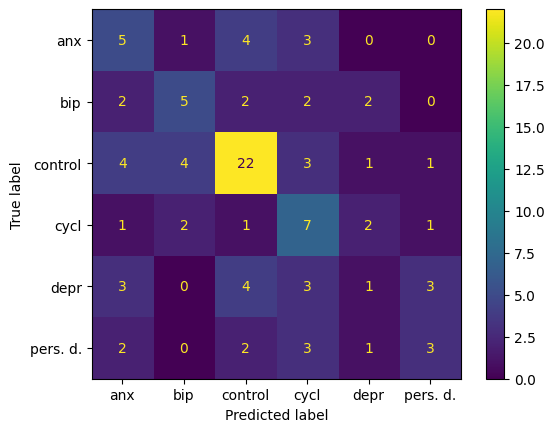

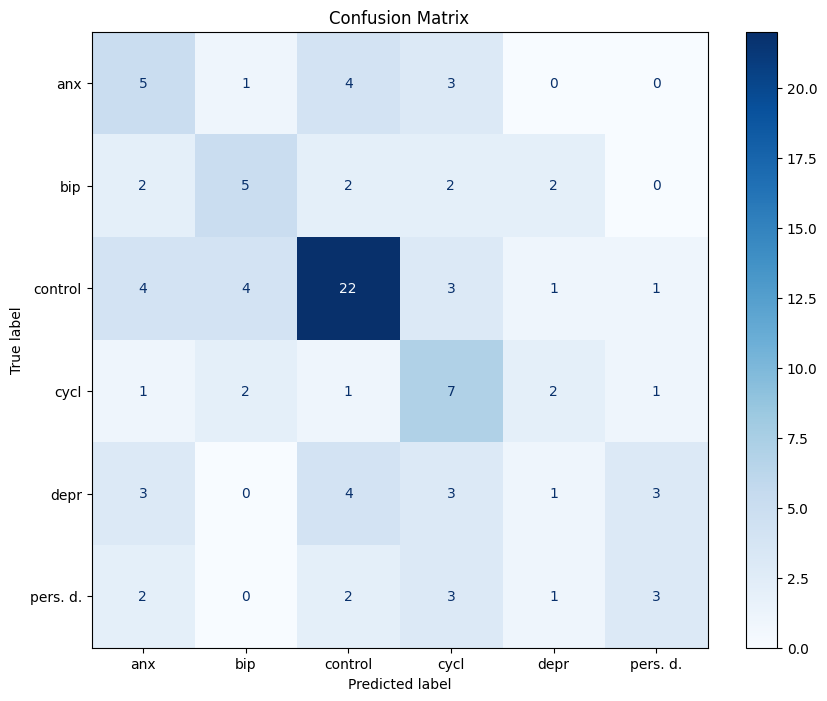

In [117]:
disp = ConfusionMatrixDisplay.from_estimator(clf, X_test, y_test, display_labels=['anx', 'bip', 'control', 'cycl', 'depr', 'pers. d.'])
fig, ax = plt.subplots(figsize=(10, 8))
disp.plot(ax=ax, cmap='Blues')

ax.set_title('Confusion Matrix')
plt.show()

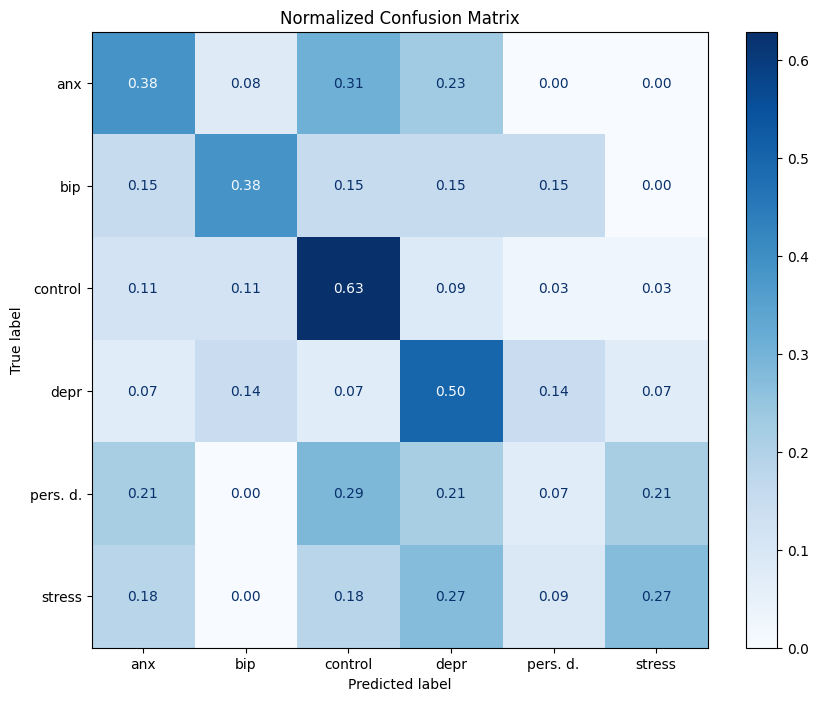

In [114]:
y_pred = clf.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

disp = ConfusionMatrixDisplay(confusion_matrix=cm_normalized,
                              display_labels=['anx', 'bip', 'control', 'depr', 'pers. d.', 'stress'])

fig, ax = plt.subplots(figsize=(10, 8))
disp.plot(ax=ax, cmap='Blues', values_format='.2f')

ax.set_title('Normalized Confusion Matrix')
plt.show()

## PR and ROC curves

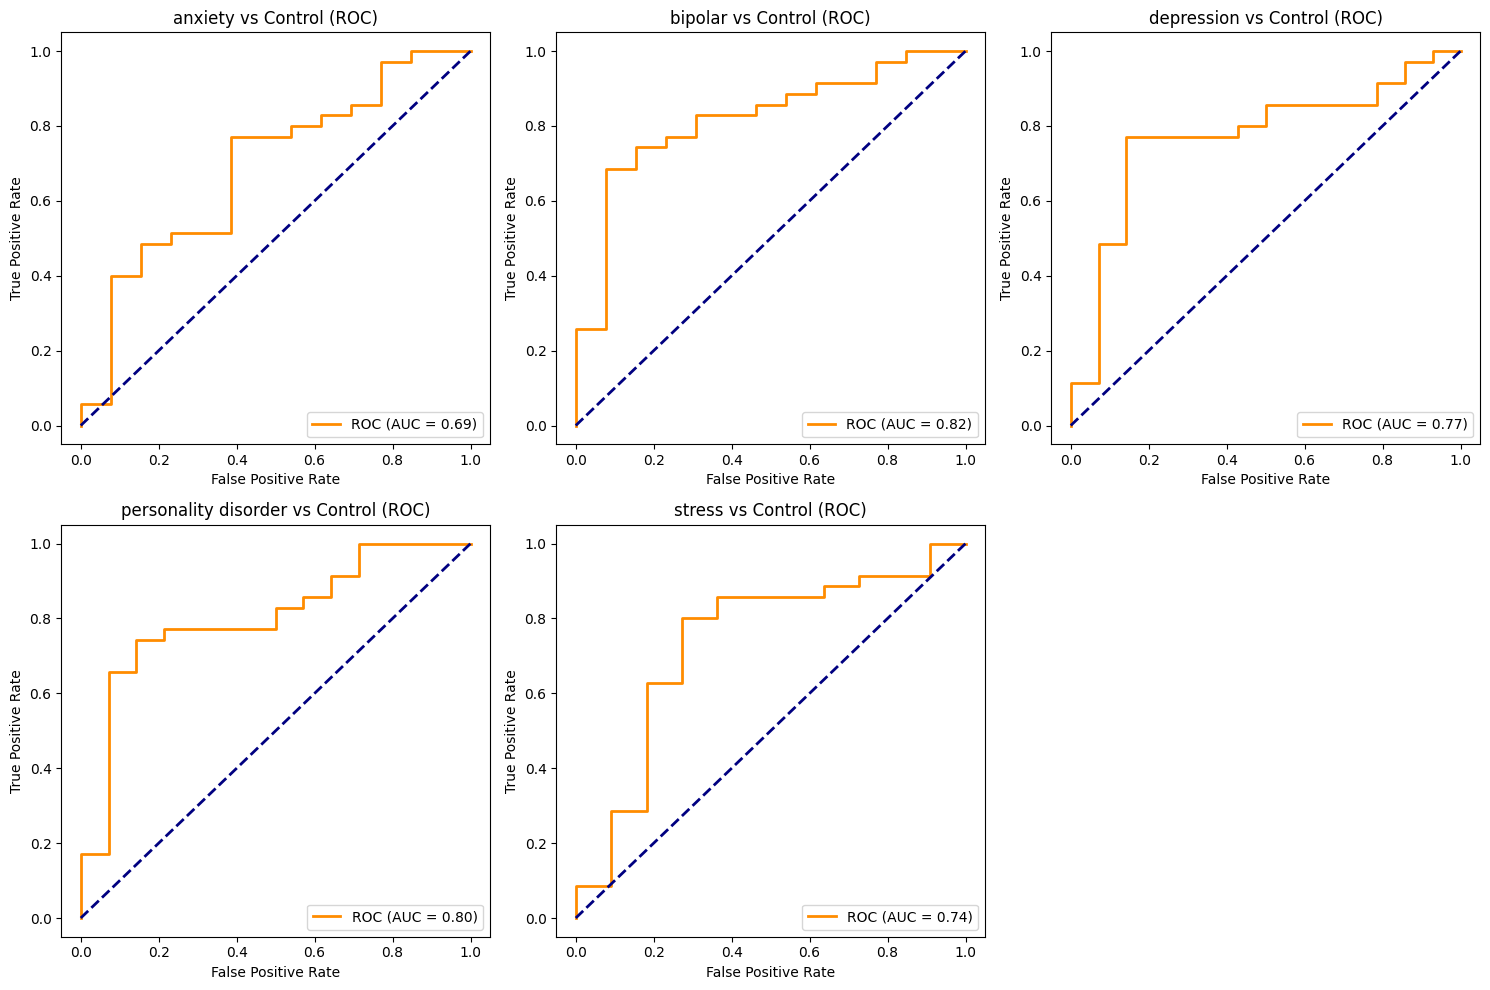

ROC AUC Scores: {0: np.float64(0.6901098901098901), 1: np.float64(0.8197802197802199), 3: np.float64(0.7714285714285715), 4: np.float64(0.8040816326530612), 5: np.float64(0.7350649350649351)}
PR AUC Scores: {0: np.float64(0.8454075149135465), 1: np.float64(0.9248987661407801), 3: np.float64(0.8881201277648804), 4: np.float64(0.9075124913797775), 5: np.float64(0.8793993468840006)}


In [171]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score
from sklearn.model_selection import train_test_split

# Define classes (assuming 'control' is index 2)
pathologies = [0, 1, 3, 4, 5]
control_class = 2

# Store results
roc_aucs = {}
pr_aucs = {}

# Initialize plots
plt.figure(figsize=(15, 10))

# --- Loop through each pathology ---
for i, pathology in enumerate(pathologies):
    # 1. Filter data (only pathology + control)
    pathology_mask = (y_test == pathology) | (y_test == control_class)
    X_test_subset = X_test[pathology_mask]
    y_test_subset = y_test[pathology_mask]
    
    # 2. Binarize labels (1 for pathology, 0 for control)
    y_test_binary = (y_test_subset == control_class).astype(int)
    
    # 3. Predict probabilities for the pathology class
    # (Note: `clf.classes_` must match the order in predict_proba)
    proba_pathology = clf.predict_proba(X_test_subset)[:, clf.classes_.tolist().index(control_class)]
    
    # --- ROC Curve ---
    fpr, tpr, _ = roc_curve(y_test_binary, proba_pathology)
    roc_auc = auc(fpr, tpr)
    roc_aucs[pathology] = roc_auc
    
    # --- PR Curve ---
    precision, recall, _ = precision_recall_curve(y_test_binary, proba_pathology)
    pr_auc = average_precision_score(y_test_binary, proba_pathology)
    pr_aucs[pathology] = pr_auc
    
    # --- Plotting ---
    # ROC
    plt.subplot(2, 3, i+1)
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC (AUC = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'{class2name[pathology]} vs Control (ROC)')
    plt.legend(loc='lower right')
    
    # # PR
    # plt.subplot(2, 3, i+2)
    # plt.plot(recall, precision, color='blue', lw=2, label=f'PR (AP = {pr_auc:.2f})')
    # plt.xlabel('Recall')
    # plt.ylabel('Precision')
    # plt.title(f'{class2name[pathology]} vs Control (PR)')
    # plt.legend(loc='upper right')

plt.tight_layout()
plt.show()

# Print AUC scores
print("ROC AUC Scores:", roc_aucs)
print("PR AUC Scores:", pr_aucs)

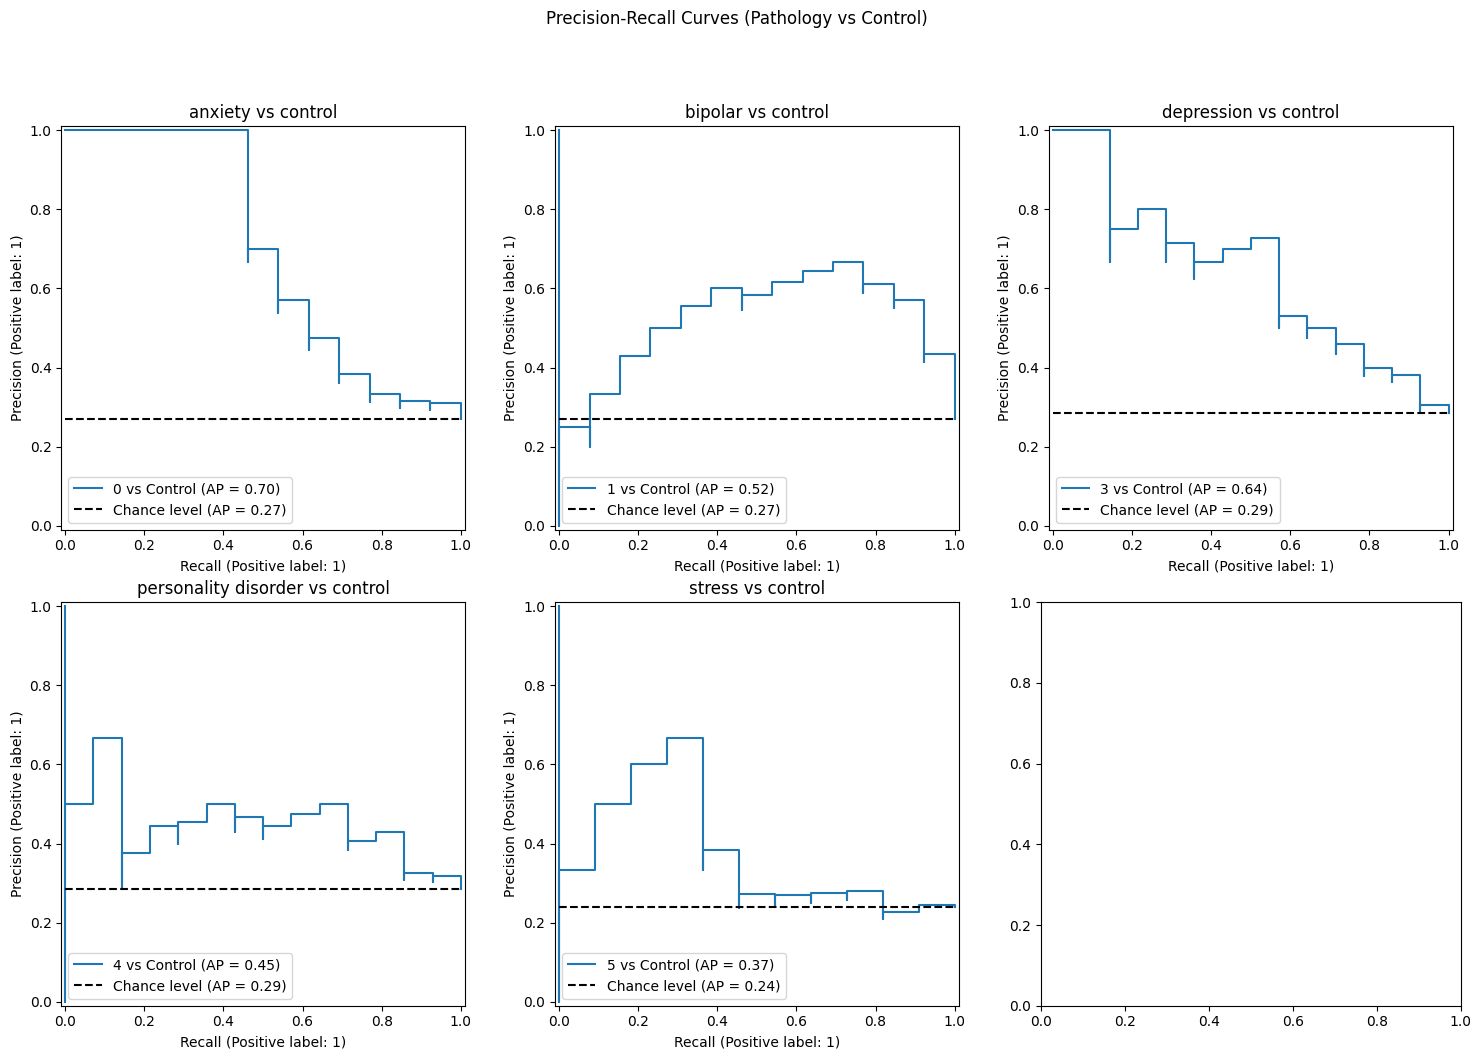

In [168]:
from sklearn.metrics import PrecisionRecallDisplay
import matplotlib.pyplot as plt
# Initialize figure
fig, axs = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Precision-Recall Curves (Pathology vs Control)', y=1.05)

col = 0
row = 0

# Loop through each pathology
for i, pathology in enumerate(pathologies):
    # 1. Filter data (only pathology + control)
    mask = (y_test == pathology) | (y_test == control_class)
    X_subset = X_test[mask]
    y_subset = y_test[mask]
    
    # 2. Binarize labels (1 for pathology, 0 for control)
    y_binary = (y_subset == pathology).astype(int)
    
    # 3. Get predicted probabilities for the pathology class
    proba_pathology = clf.predict_proba(X_subset)[:, clf.classes_.tolist().index(pathology)]
    
    # 4. Plot PR curve using PrecisionRecallDisplay
    PrecisionRecallDisplay.from_predictions(
        y_binary,
        proba_pathology,
        name=f'{pathology} vs Control',
        ax=axs[row, col], 
        plot_chance_level=True
    )
    
    axs[row, col].set_title(f'{class2name[pathology]} vs control')
    axs[row, col].legend(loc='lower left')
    col += 1
    if col == 3:
        row += 1
        col = 0

plt.tight_layout()
plt.show()

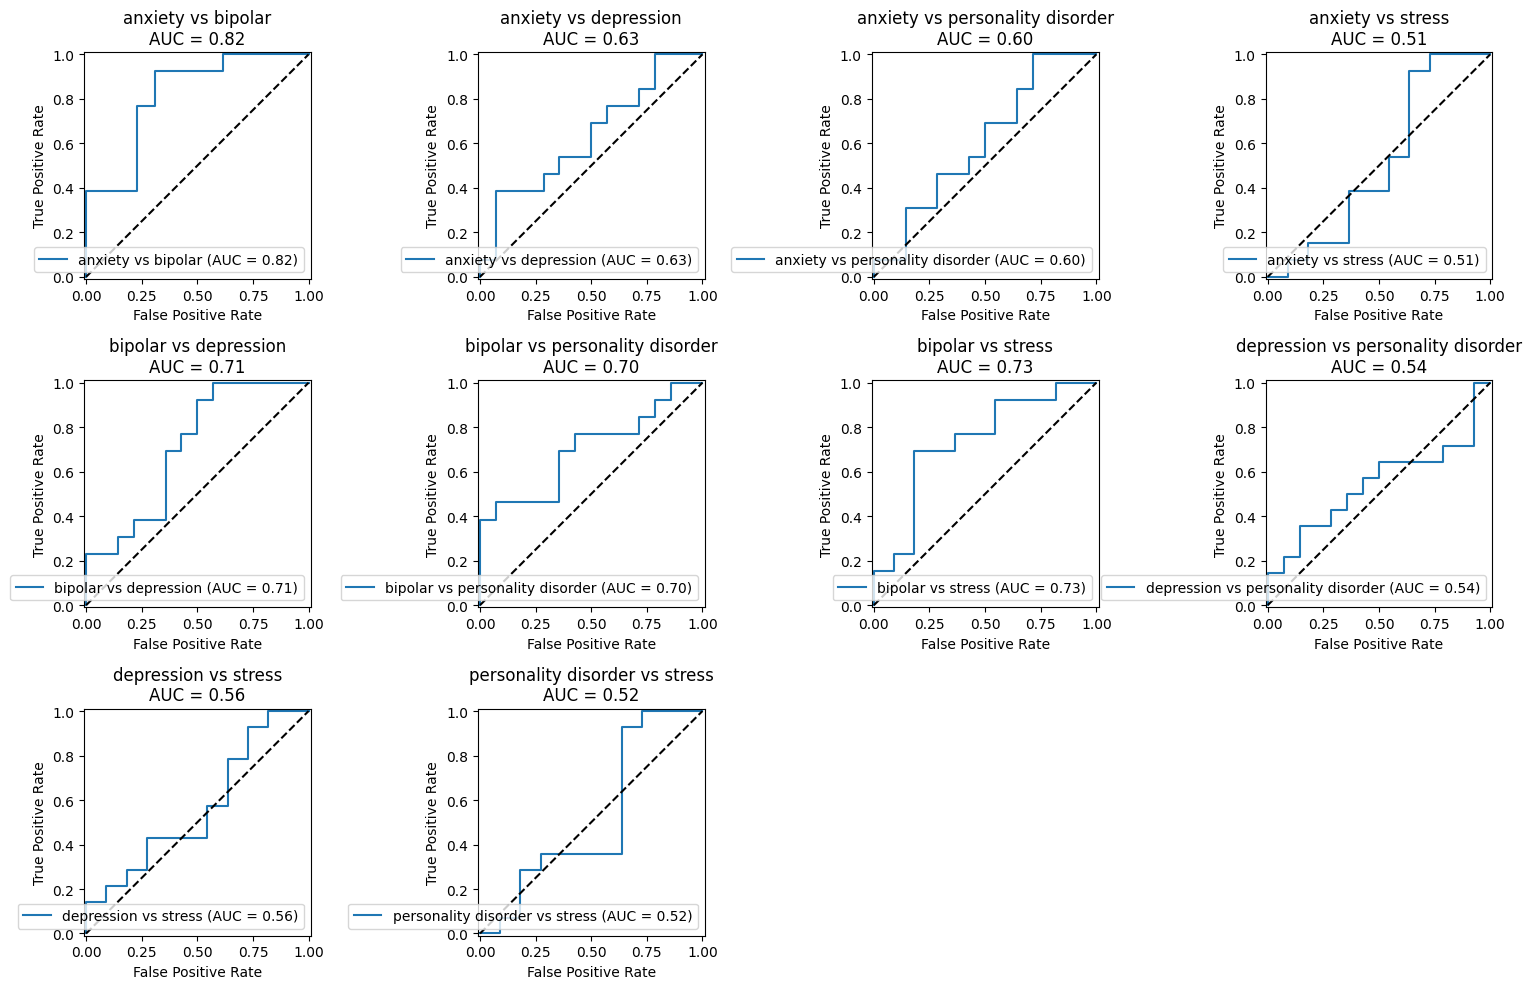

In [170]:
from sklearn.metrics import RocCurveDisplay, auc
import matplotlib.pyplot as plt
import numpy as np
from itertools import combinations

# Define all pathology classes (excluding 'control')
pathologies = [0, 1, 3, 4, 5]

# Generate all possible pairs of pathologies
pathology_pairs = list(combinations(pathologies, 2))

# Initialize figure
plt.figure(figsize=(15, 10))

# Loop through each pathology pair
for i, (class1, class2) in enumerate(pathology_pairs):
    # 1. Filter data (only the two pathologies in the pair)
    mask = (y_test == class1) | (y_test == class2)
    X_pair = X_test[mask]
    y_pair = y_test[mask]
    
    # 2. Binarize labels (1 for class1, 0 for class2)
    y_binary = (y_pair == class1).astype(int)
    
    # 3. Get predicted probabilities for class1
    probs = clf.predict_proba(X_pair)
    proba_class1 = probs[:, clf.classes_.tolist().index(class1)]
    proba_class2 = probs[:, clf.classes_.tolist().index(class2)]
    normed_probs = proba_class1 / (proba_class1 + proba_class2)
    
    # 4. Compute ROC curve and AUC
    fpr, tpr, _ = roc_curve(y_binary, normed_probs)
    roc_auc = auc(fpr, tpr)
    
    # 5. Plot ROC curve
    plt.subplot(3, 4, i+1)  # Adjust subplot grid as needed
    RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc, estimator_name=f'{class2name[class1]} vs {class2name[class2]}').plot(ax=plt.gca())
    plt.title(f'{class2name[class1]} vs {class2name[class2]}\nAUC = {roc_auc:.2f}')
    plt.plot([0, 1], [0, 1], 'k--')  # Diagonal line for random guessing

plt.tight_layout()
plt.show()

## Only zg

In [21]:
len(band2features_zg[(1, 30)])

455

In [22]:
channels2use = ['Fp1', 'Fp2', 'F3', 'Fz', 'F4', 'F7', 'F8', 'T3', 'T4', 'C3', 'Cz', 'C4', 'T5', 'T6', 'P3', 'Pz', 'P4', 'O1', 'O2']
freq_bands = [(8, 13), (13, 26)]

band2features = {fb: [] for fb in freq_bands}
band2features[(8, 26)] = []

to_skip = ['BORUTTO_JANNA_VLADIMIROVNA', 'Kutuz_f23_contr', 'MANUILOVA_ELENA_55', 'Martinenko_m45', 'Skopincev_20', 'FiAV_m50']

for i in tqdm(range(len(zg_files))):
    path = zg_files[i]
    if any([x in path for x in to_skip]):
        continue
    try:
        sample_zg = mne.io.read_raw_edf(path, verbose=False, preload=True).filter(l_freq=1, h_freq=30, method='iir', verbose=False)
    except Exception as e:
        print(f'skipped {path}')
        continue
    # skip faulty data for now
    if 'chan' in sample.ch_names[0].lower():
        print(f'skipped {path}')
        continue
    # get only necessary channels, reorder them
    channels_zg = sample_zg.ch_names
    new_idx_zg = []
    skip = False
    for ch in channels2use:
        found_zg = False
        for k in range(19):
            if ch in channels_zg[k]:
                new_idx_zg.append(k)
                found_zg = True
            if found_zg:
                break
        if not found_zg:
            skip = True
            break
    if skip:
        print(f'skipped {path}')
        continue
    
    s_freq = int(sample_zg.info['sfreq'])
    data_zg = sample_zg.get_data()[new_idx_zg, :int(20 * s_freq)]

    for freq_band in freq_bands:
        psd, freqs = mne.time_frequency.psd_array_multitaper(data_zg, sfreq=s_freq, fmin=freq_band[0], fmax=freq_band[1], normalization='length', verbose=False)
        band2features[freq_band].append({
            'frontal2parietal': get_frontal2parietal_gradient(channels_zg, psd),
            'front2back': get_front2back_gradient(channels_zg, psd),
            'left2right': get_left2right_gradient(channels_zg, psd),
            'label': zg_labels[i]
        })
    psd, freqs = mne.time_frequency.psd_array_multitaper(data_zg, sfreq=s_freq, fmin=8, fmax=26, normalization='length', verbose=False)
    band2features[(8, 26)].append({
        'features': extract_features(data_zg, s_freq).flatten(),
        'label': zg_labels[i]
    })
    

num_samples = len(band2features[freq_bands[0]])
frontal2parietal_features = [np.concatenate([band2features[freq_bands[0]][i]['frontal2parietal'], band2features[freq_bands[1]][i]['frontal2parietal']]) for i in range(num_samples)]
front2back_features = [np.concatenate([band2features[freq_bands[0]][i]['front2back'], band2features[freq_bands[1]][i]['front2back']]) for i in range(num_samples)]
left2right_features = [np.concatenate([band2features[freq_bands[0]][i]['left2right'], band2features[freq_bands[1]][i]['left2right']]) for i in range(num_samples)]
# other_features = [np.concatenate([band2features[freq_bands[0]][i]['features'], band2features[freq_bands[1]][i]['features']]) for i in range(num_samples)]
other_features = [band2features[(8, 26)][i]['features'].flatten() for i in range(num_samples)]
labels = [label2class[x['label']] for x in band2features[freq_bands[0]]]

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=92)

features = []
for i in range(len(labels)):
    features.append(np.concatenate([frontal2parietal_features[i], front2back_features[i], left2right_features[i], other_features[i]]))
f1_scores = []
for i, (train, test) in enumerate(kf.split(list(range(len(labels))), labels)):
    clf = SVC(kernel='linear', random_state=92)
    X_train = np.array(features)[train]
    X_test = np.array(features)[test]
    y_train = np.array(labels)[train]
    y_test = np.array(labels)[test]
    clf.fit(X_train, y_train)   
    f1_scores.append(f1_score(y_test, clf.predict(X_test), average='macro'))

# print(f'Frequency band: {freq_band}')
print(f'\tF1 score: {np.mean(f1_scores)}, std: {np.std(f1_scores)}')

new_ids = [i for i in range(len(labels)) if labels[i] != 5]
new_labels = [labels[i] for i in range(len(labels)) if labels[i] != 5]
features = []
for i in new_ids:
    features.append(np.concatenate([frontal2parietal_features[i], front2back_features[i], left2right_features[i], other_features[i]]))
f1_scores = []
for i, (train, test) in enumerate(kf.split(list(range(len(new_labels))), new_labels)):
    clf = SVC(kernel='linear', random_state=92)
    X_train = np.array(features)[train]
    X_test = np.array(features)[test]
    y_train = np.array(labels)[train]
    y_test = np.array(labels)[test]
    clf.fit(X_train, y_train)   
    f1_scores.append(f1_score(y_test, clf.predict(X_test), average='macro'))

# print(f'Frequency band: {freq_band}')
print(f'\tF1 score, wo stress: {np.mean(f1_scores)}, std: {np.std(f1_scores)}')

  0%|          | 0/503 [00:00<?, ?it/s]

	F1 score: 0.31488846924935554, std: 0.03309071008190511
	F1 score, wo stress: 0.3237625075855867, std: 0.03329816312940547


In [23]:
with open('features_zg_band.pkl', 'wb') as f:
        pickle.dump(band2features, f)

# Envelope features

In [31]:
import numpy as np
import mne
from scipy.signal import hilbert
from mne_connectivity import envelope_correlation

FREQ_BANDS = {
    'delta': (1, 4),
    'theta': (4, 8),
    'alpha': (8, 13),
    'beta': (13, 30),
    'alpha_low': (8, 10),
    'alpha_high': (10, 13),
    'beta_low': (13, 20),
    'beta_high': (20, 30)
}

FREQ_BANDS_V2 = {
    'delta': (1, 4),
    'theta': (4, 8),
    'alpha': (8, 12),
    'beta': (12, 30)
}

def compute_envelope_features(epochs, freq_bands):
    envelope_features = []
    for band, (l_freq, h_freq) in freq_bands.items():
        # Band-pass filter
        epochs_band = epochs.copy().filter(l_freq=l_freq, h_freq=h_freq, verbose=False)
        data = epochs_band.get_data()  # Shape (n_epochs, n_channels, n_times)
        
        # Compute envelope using Hilbert transform
        analytic = hilbert(data)
        envelope = np.abs(analytic)
        
        # Compute statistics (mean and standard deviation)
        mean_env = np.mean(envelope, axis=-1)  # (n_epochs, n_channels)
        std_env = np.std(envelope, axis=-1)
        
        # Concatenate features for this band
        features = np.concatenate([mean_env, std_env], axis=0)
        envelope_features.append(features)
    
    return np.hstack(envelope_features)

def compute_correlation_features(epochs, freq_bands, low_pass=4, new_sfreq=8):
    corr_features = []
    sfreq = epochs.info['sfreq']
    
    for band, (l_freq, h_freq) in freq_bands.items():
        # Band-pass filter
        epochs_band = epochs.copy().filter(l_freq=l_freq, h_freq=h_freq, verbose=False)
        data = epochs_band.get_data()  # Shape (n_epochs, n_channels, n_times)
        
        # Compute envelope
        analytic = hilbert(data)
        envelope = np.abs(analytic)
        
        # Low-pass filter the envelope
        envelope_low = mne.filter.filter_data(
            envelope, sfreq=sfreq, l_freq=None, h_freq=low_pass, method='iir', verbose=False
        )
        
        # Downsample the envelope
        envelope_down = mne.filter.resample(
            envelope_low, down=sfreq / new_sfreq, axis=-1, verbose=False
        )
        
        # Compute envelope correlations
        n_channels, _ = envelope_down.shape
        corr = np.corrcoef(envelope_down)
        
        # Extract upper triangle indices
        triu_inds = np.triu_indices(n_channels, k=1)
        corr_flat = corr[triu_inds[0], triu_inds[1]]
        corr_features.append(corr_flat)
    
    return np.hstack(corr_features) 

## Open eyes

In [32]:
channels2use = ['Fp1', 'Fp2', 'F3', 'Fz', 'F4', 'F7', 'F8', 'T3', 'T4', 'C3', 'Cz', 'C4', 'T5', 'T6', 'P3', 'Pz', 'P4', 'O1', 'O2']

classifiers = {'SVM': SVC(random_state=92), 'KNN': KNeighborsClassifier()}

cleaned_labels_og = []
envelopes_og = []
correlations_og = []

for i in tqdm(range(len(og_files))):
    path = og_files[i]
    try:
        sample = mne.io.read_raw_edf(path, verbose=False, preload=True)
    except Exception as e:
        print(f'skipped {path}')
        continue
    # skip faulty data for now
    if 'chan' in sample.ch_names[0].lower():
        print(f'skipped {path}')
        continue
    sample = sample.filter(l_freq=1, h_freq=30, method='iir', verbose=False)
    # get only necessary channels, reorder them
    channels = sample.ch_names
    to_drop = channels[19:]
    sample.drop_channels(to_drop)
    new_idx = []
    skip = False
    for ch in channels2use:
        found = False
        for k in range(19):
            if ch in channels[k]:
                new_idx.append(k)
                found = True
                break
        if not found:
            skip = True
            break
    if skip:
        print(f'skipped {path}')
        continue
    
    sample_copy = sample.copy()
    sample_copy = sample_copy.resample(100)
    sample_copy = sample_copy.pick_channels([channels[j] for j in new_idx], verbose=False)
    sample_copy = sample_copy.crop(0, 19)
    envelopes_og.append(compute_envelope_features(sample_copy, FREQ_BANDS))
    correlations_og.append(compute_correlation_features(sample_copy, FREQ_BANDS))
    cleaned_labels_og.append(label2class[og_labels[i]])

  0%|          | 0/503 [00:00<?, ?it/s]

skipped OCD/controls (157)/BORUTTO_JANNA_VLADIMIROVNA_48_EO_free.edf
skipped OCD/controls (157)/Kutuz_f23_contr_og.edf
skipped OCD/controls (157)/MANUILOVA_ELENA_55_og.edf
skipped OCD/controls (157)/Martinenko_m45_og.edf
skipped OCD/controls (157)/Skopincev_20_EO_free.edf
skipped OCD/depression_moderade (47)/FiAV_m50_f32-1_At_Nt_og.edf


In [33]:
envelopes_og = np.array(envelopes_og)
correlations_og = np.array(correlations_og)
labels = np.array(cleaned_labels_og)

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=92)

f1_scores = []
for i, (train, test) in enumerate(kf.split(list(range(len(labels))), labels)):
    X_train = np.concatenate([envelopes_og[train], correlations_og[train]], axis=1)
    X_test = np.concatenate([envelopes_og[test], correlations_og[test]], axis=1)
    y_train = labels[train]
    y_test = labels[test]
    clf = SVC(kernel='linear', class_weight='balanced', random_state=92)
    clf.fit(X_train, y_train)
    preds = clf.predict(X_test)
    f1_scores.append(f1_score(y_test, preds, average='macro'))
print(f'SVM F1 score: {np.mean(f1_scores)}, std: {np.std(f1_scores)}')

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=92)

f1_scores = []
for i, (train, test) in enumerate(kf.split(list(range(len(labels))), labels)):
    X_train = np.concatenate([envelopes_og[train], correlations_og[train]], axis=1)
    X_test = np.concatenate([envelopes_og[test], correlations_og[test]], axis=1)
    y_train = labels[train]
    y_test = labels[test]
    clf = KNeighborsClassifier(weights='distance')
    clf.fit(X_train, y_train)
    preds = clf.predict(X_test)
    f1_scores.append(f1_score(y_test, preds, average='macro'))
print(f'KNN F1 score: {np.mean(f1_scores)}, std: {np.std(f1_scores)}')

f1_scores = []
for i, (train, test) in enumerate(kf.split(list(range(len(labels))), labels)):
    X_train = np.concatenate([envelopes_og[train], correlations_og[train]], axis=1)
    X_test = np.concatenate([envelopes_og[test], correlations_og[test]], axis=1)
    y_train = labels[train]
    y_test = labels[test]
    clf = KNeighborsClassifier()
    clf.fit(X_train, y_train)
    preds = clf.predict(X_test)
    f1_scores.append(f1_score(y_test, preds, average='macro'))
print(f'KNN, no weights F1 score: {np.mean(f1_scores)}, std: {np.std(f1_scores)}')

SVM F1 score: 0.3724569687260039, std: 0.04174186000012747
KNN F1 score: 0.3169275893180391, std: 0.04945969249494864
KNN, no weights F1 score: 0.22552171628813364, std: 0.03961853534160384


In [34]:
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=92)

f1_scores = []
for i, (train, test) in enumerate(kf.split(list(range(len(labels))), labels)):
    X_train = envelopes_og[train]
    X_test = envelopes_og[test]
    y_train = labels[train]
    y_test = labels[test]
    clf = SVC(kernel='linear', class_weight='balanced', random_state=92)
    clf.fit(X_train, y_train)
    preds = clf.predict(X_test)
    f1_scores.append(f1_score(y_test, preds, average='macro'))
print(f'SVM F1 score: {np.mean(f1_scores)}, std: {np.std(f1_scores)}')

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=92)

f1_scores = []
for i, (train, test) in enumerate(kf.split(list(range(len(labels))), labels)):
    X_train = envelopes_og[train]
    X_test = envelopes_og[test]
    y_train = labels[train]
    y_test = labels[test]
    clf = KNeighborsClassifier(weights='distance')
    clf.fit(X_train, y_train)
    preds = clf.predict(X_test)
    f1_scores.append(f1_score(y_test, preds, average='macro'))
print(f'KNN F1 score: {np.mean(f1_scores)}, std: {np.std(f1_scores)}')

SVM F1 score: 0.060603038328402734, std: 0.014290897157939748
KNN F1 score: 0.3509505793993801, std: 0.05483498199009271


In [35]:
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=92)

f1_scores = []
for i, (train, test) in enumerate(kf.split(list(range(len(labels))), labels)):
    X_train = correlations_og[train]
    X_test = correlations_og[test]
    y_train = labels[train]
    y_test = labels[test]
    clf = SVC(kernel='linear', class_weight='balanced', random_state=92)
    clf.fit(X_train, y_train)
    preds = clf.predict(X_test)
    f1_scores.append(f1_score(y_test, preds, average='macro'))
print(f'SVM F1 score: {np.mean(f1_scores)}, std: {np.std(f1_scores)}')

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=92)

f1_scores = []
for i, (train, test) in enumerate(kf.split(list(range(len(labels))), labels)):
    X_train = correlations_og[train]
    X_test = correlations_og[test]
    y_train = labels[train]
    y_test = labels[test]
    clf = KNeighborsClassifier(weights='distance')
    clf.fit(X_train, y_train)
    preds = clf.predict(X_test)
    f1_scores.append(f1_score(y_test, preds, average='macro'))
print(f'KNN F1 score: {np.mean(f1_scores)}, std: {np.std(f1_scores)}')

SVM F1 score: 0.3724569687260039, std: 0.04174186000012747
KNN F1 score: 0.3169275893180391, std: 0.04945969249494864


In [36]:
correlations_og.shape

(497, 1368)

In [41]:
channels2use = ['Fp1', 'Fp2', 'F3', 'Fz', 'F4', 'F7', 'F8', 'T3', 'T4', 'C3', 'Cz', 'C4', 'T5', 'T6', 'P3', 'Pz', 'P4', 'O1', 'O2']

classifiers = {'SVM': SVC(random_state=92), 'KNN': KNeighborsClassifier()}

cleaned_labels_og = []
envelopes_og = []
correlations_og = []

for i in tqdm(range(len(og_files))):
    path = og_files[i]
    try:
        sample = mne.io.read_raw_edf(path, verbose=False, preload=True)
    except Exception as e:
        print(f'skipped {path}')
        continue
    # skip faulty data for now
    if 'chan' in sample.ch_names[0].lower():
        print(f'skipped {path}')
        continue
    sample = sample.filter(l_freq=1, h_freq=30, method='iir', verbose=False)
    # get only necessary channels, reorder them
    channels = sample.ch_names
    to_drop = channels[19:]
    sample.drop_channels(to_drop)
    new_idx = []
    skip = False
    for ch in channels2use:
        found = False
        for k in range(19):
            if ch in channels[k]:
                new_idx.append(k)
                found = True
                break
        if not found:
            skip = True
            break
    if skip:
        print(f'skipped {path}')
        continue
    
    sample_copy = sample.copy()
    sample_copy = sample_copy.resample(100)
    sample_copy = sample_copy.pick_channels([channels[j] for j in new_idx], verbose=False)
    sample_copy = sample_copy.crop(0, 19)
    envelopes_og.append(compute_envelope_features(sample_copy, FREQ_BANDS_V2))
    correlations_og.append(compute_correlation_features(sample_copy, FREQ_BANDS_V2))
    cleaned_labels_og.append(label2class[og_labels[i]])

  0%|          | 0/503 [00:00<?, ?it/s]

skipped OCD/controls (157)/BORUTTO_JANNA_VLADIMIROVNA_48_EO_free.edf
skipped OCD/controls (157)/Kutuz_f23_contr_og.edf
skipped OCD/controls (157)/MANUILOVA_ELENA_55_og.edf
skipped OCD/controls (157)/Martinenko_m45_og.edf
skipped OCD/controls (157)/Skopincev_20_EO_free.edf
skipped OCD/depression_moderade (47)/FiAV_m50_f32-1_At_Nt_og.edf


In [42]:
envelopes_og = np.array(envelopes_og)
correlations_og = np.array(correlations_og)
labels = np.array(cleaned_labels_og)

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=92)

f1_scores = []
for i, (train, test) in enumerate(kf.split(list(range(len(labels))), labels)):
    X_train = np.concatenate([envelopes_og[train], correlations_og[train]], axis=1)
    X_test = np.concatenate([envelopes_og[test], correlations_og[test]], axis=1)
    y_train = labels[train]
    y_test = labels[test]
    clf = SVC(kernel='linear', class_weight='balanced', random_state=92)
    clf.fit(X_train, y_train)
    preds = clf.predict(X_test)
    f1_scores.append(f1_score(y_test, preds, average='macro'))
print(f'SVM F1 score: {np.mean(f1_scores)}, std: {np.std(f1_scores)}')

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=92)

f1_scores = []
for i, (train, test) in enumerate(kf.split(list(range(len(labels))), labels)):
    X_train = np.concatenate([envelopes_og[train], correlations_og[train]], axis=1)
    X_test = np.concatenate([envelopes_og[test], correlations_og[test]], axis=1)
    y_train = labels[train]
    y_test = labels[test]
    clf = KNeighborsClassifier(weights='distance')
    clf.fit(X_train, y_train)
    preds = clf.predict(X_test)
    f1_scores.append(f1_score(y_test, preds, average='macro'))
print(f'KNN F1 score: {np.mean(f1_scores)}, std: {np.std(f1_scores)}')

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=92)

f1_scores = []
for i, (train, test) in enumerate(kf.split(list(range(len(labels))), labels)):
    X_train = envelopes_og[train]
    X_test = envelopes_og[test]
    y_train = labels[train]
    y_test = labels[test]
    clf = SVC(kernel='linear', class_weight='balanced', random_state=92)
    clf.fit(X_train, y_train)
    preds = clf.predict(X_test)
    f1_scores.append(f1_score(y_test, preds, average='macro'))
print(f'SVM F1 score: {np.mean(f1_scores)}, std: {np.std(f1_scores)}')

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=92)

f1_scores = []
for i, (train, test) in enumerate(kf.split(list(range(len(labels))), labels)):
    X_train = envelopes_og[train]
    X_test = envelopes_og[test]
    y_train = labels[train]
    y_test = labels[test]
    clf = KNeighborsClassifier(weights='distance')
    clf.fit(X_train, y_train)
    preds = clf.predict(X_test)
    f1_scores.append(f1_score(y_test, preds, average='macro'))
print(f'KNN F1 score: {np.mean(f1_scores)}, std: {np.std(f1_scores)}')

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=92)

f1_scores = []
for i, (train, test) in enumerate(kf.split(list(range(len(labels))), labels)):
    X_train = correlations_og[train]
    X_test = correlations_og[test]
    y_train = labels[train]
    y_test = labels[test]
    clf = SVC(kernel='linear', class_weight='balanced', random_state=92)
    clf.fit(X_train, y_train)
    preds = clf.predict(X_test)
    f1_scores.append(f1_score(y_test, preds, average='macro'))
print(f'SVM F1 score: {np.mean(f1_scores)}, std: {np.std(f1_scores)}')

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=92)

f1_scores = []
for i, (train, test) in enumerate(kf.split(list(range(len(labels))), labels)):
    X_train = correlations_og[train]
    X_test = correlations_og[test]
    y_train = labels[train]
    y_test = labels[test]
    clf = KNeighborsClassifier(weights='distance')
    clf.fit(X_train, y_train)
    preds = clf.predict(X_test)
    f1_scores.append(f1_score(y_test, preds, average='macro'))
print(f'KNN F1 score: {np.mean(f1_scores)}, std: {np.std(f1_scores)}')

SVM F1 score: 0.35472428784061194, std: 0.020869685201034802
KNN F1 score: 0.29804498050238953, std: 0.031444550844639145
SVM F1 score: 0.060603038328402734, std: 0.014290897157939748
KNN F1 score: 0.3522363473986396, std: 0.053517124022813924
SVM F1 score: 0.35472428784061194, std: 0.020869685201034802
KNN F1 score: 0.29804498050238953, std: 0.031444550844639145


In [45]:
correlations_og.shape

(497, 684)

## Closed eyes

In [37]:
channels2use = ['Fp1', 'Fp2', 'F3', 'Fz', 'F4', 'F7', 'F8', 'T3', 'T4', 'C3', 'Cz', 'C4', 'T5', 'T6', 'P3', 'Pz', 'P4', 'O1', 'O2']

classifiers = {'SVM': SVC(random_state=92), 'KNN': KNeighborsClassifier()}
to_skip = ['BORUTTO_JANNA_VLADIMIROVNA', 'Kutuz_f23_contr', 'MANUILOVA_ELENA_55', 'Martinenko_m45', 'Skopincev_20', 'FiAV_m50']

cleaned_labels_zg = []
envelopes_zg = []
correlations_zg = []

for i in tqdm(range(len(zg_files))):
    path = zg_files[i]
    if any(skip in path for skip in to_skip):
        continue
    try:
        sample = mne.io.read_raw_edf(path, verbose=False, preload=True)
    except Exception as e:
        print(f'skipped {path}')
        continue
    # skip faulty data for now
    if 'chan' in sample.ch_names[0].lower():
        print(f'skipped {path}')
        continue
    sample = sample.filter(l_freq=1, h_freq=30, method='iir', verbose=False)
    # get only necessary channels, reorder them
    channels = sample.ch_names
    to_drop = channels[19:]
    sample.drop_channels(to_drop)
    new_idx = []
    skip = False
    for ch in channels2use:
        found = False
        for k in range(19):
            if ch in channels[k]:
                new_idx.append(k)
                found = True
                break
        if not found:
            skip = True
            break
    if skip:
        print(f'skipped {path}')
        continue
    
    sample_copy = sample.copy()
    sample_copy = sample_copy.resample(100)
    sample_copy = sample_copy.pick_channels([channels[j] for j in new_idx], verbose=False)
    sample_copy = sample_copy.crop(0, 19)
    envelopes_zg.append(compute_envelope_features(sample_copy, FREQ_BANDS))
    correlations_zg.append(compute_correlation_features(sample_copy, FREQ_BANDS))
    cleaned_labels_zg.append(label2class[zg_labels[i]])

  0%|          | 0/503 [00:00<?, ?it/s]

In [38]:
envelopes_zg = np.array(envelopes_zg)
correlations_zg = np.array(correlations_zg)
labels = np.array(cleaned_labels_zg)

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=92)

f1_scores = []
for i, (train, test) in enumerate(kf.split(list(range(len(labels))), labels)):
    X_train = np.concatenate([envelopes_zg[train], correlations_zg[train]], axis=1)
    X_test = np.concatenate([envelopes_zg[test], correlations_zg[test]], axis=1)
    y_train = labels[train]
    y_test = labels[test]
    clf = SVC(kernel='linear', class_weight='balanced', random_state=92)
    clf.fit(X_train, y_train)
    preds = clf.predict(X_test)
    f1_scores.append(f1_score(y_test, preds, average='macro'))
print(f'SVM F1 score: {np.mean(f1_scores)}, std: {np.std(f1_scores)}')

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=92)

f1_scores = []
for i, (train, test) in enumerate(kf.split(list(range(len(labels))), labels)):
    X_train = np.concatenate([envelopes_zg[train], correlations_zg[train]], axis=1)
    X_test = np.concatenate([envelopes_zg[test], correlations_zg[test]], axis=1)
    y_train = labels[train]
    y_test = labels[test]
    clf = KNeighborsClassifier(weights='distance')
    clf.fit(X_train, y_train)
    preds = clf.predict(X_test)
    f1_scores.append(f1_score(y_test, preds, average='macro'))
print(f'KNN F1 score: {np.mean(f1_scores)}, std: {np.std(f1_scores)}')

f1_scores = []
for i, (train, test) in enumerate(kf.split(list(range(len(labels))), labels)):
    X_train = np.concatenate([envelopes_zg[train], correlations_zg[train]], axis=1)
    X_test = np.concatenate([envelopes_zg[test], correlations_zg[test]], axis=1)
    y_train = labels[train]
    y_test = labels[test]
    clf = KNeighborsClassifier()
    clf.fit(X_train, y_train)
    preds = clf.predict(X_test)
    f1_scores.append(f1_score(y_test, preds, average='macro'))
print(f'KNN, no weights F1 score: {np.mean(f1_scores)}, std: {np.std(f1_scores)}')

SVM F1 score: 0.36402844900741677, std: 0.04355799456294122
KNN F1 score: 0.3511007210199151, std: 0.034728781716798274
KNN, no weights F1 score: 0.27630666631266176, std: 0.03371076966613761


In [39]:
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=92)

f1_scores = []
for i, (train, test) in enumerate(kf.split(list(range(len(labels))), labels)):
    X_train = envelopes_zg[train]
    X_test = envelopes_zg[test]
    y_train = labels[train]
    y_test = labels[test]
    clf = SVC(kernel='linear', class_weight='balanced', random_state=92)
    clf.fit(X_train, y_train)
    preds = clf.predict(X_test)
    f1_scores.append(f1_score(y_test, preds, average='macro'))
print(f'SVM F1 score: {np.mean(f1_scores)}, std: {np.std(f1_scores)}')

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=92)

f1_scores = []
for i, (train, test) in enumerate(kf.split(list(range(len(labels))), labels)):
    X_train = envelopes_zg[train]
    X_test = envelopes_zg[test]
    y_train = labels[train]
    y_test = labels[test]
    clf = KNeighborsClassifier(weights='distance')
    clf.fit(X_train, y_train)
    preds = clf.predict(X_test)
    f1_scores.append(f1_score(y_test, preds, average='macro'))
print(f'KNN F1 score: {np.mean(f1_scores)}, std: {np.std(f1_scores)}')

SVM F1 score: 0.060603038328402734, std: 0.014290897157939748
KNN F1 score: 0.38925086215900806, std: 0.03467292793768376


In [40]:
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=92)

f1_scores = []
for i, (train, test) in enumerate(kf.split(list(range(len(labels))), labels)):
    X_train = correlations_zg[train]
    X_test = correlations_zg[test]
    y_train = labels[train]
    y_test = labels[test]
    clf = SVC(kernel='linear', class_weight='balanced', random_state=92)
    clf.fit(X_train, y_train)
    preds = clf.predict(X_test)
    f1_scores.append(f1_score(y_test, preds, average='macro'))
print(f'SVM F1 score: {np.mean(f1_scores)}, std: {np.std(f1_scores)}')

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=92)

f1_scores = []
for i, (train, test) in enumerate(kf.split(list(range(len(labels))), labels)):
    X_train = correlations_zg[train]
    X_test = correlations_zg[test]
    y_train = labels[train]
    y_test = labels[test]
    clf = KNeighborsClassifier(weights='distance')
    clf.fit(X_train, y_train)
    preds = clf.predict(X_test)
    f1_scores.append(f1_score(y_test, preds, average='macro'))
print(f'KNN F1 score: {np.mean(f1_scores)}, std: {np.std(f1_scores)}')

SVM F1 score: 0.36402844900741677, std: 0.04355799456294122
KNN F1 score: 0.3511007210199151, std: 0.034728781716798274


In [43]:
channels2use = ['Fp1', 'Fp2', 'F3', 'Fz', 'F4', 'F7', 'F8', 'T3', 'T4', 'C3', 'Cz', 'C4', 'T5', 'T6', 'P3', 'Pz', 'P4', 'O1', 'O2']

classifiers = {'SVM': SVC(random_state=92), 'KNN': KNeighborsClassifier()}
to_skip = ['BORUTTO_JANNA_VLADIMIROVNA', 'Kutuz_f23_contr', 'MANUILOVA_ELENA_55', 'Martinenko_m45', 'Skopincev_20', 'FiAV_m50']

cleaned_labels_zg = []
envelopes_zg = []
correlations_zg = []

for i in tqdm(range(len(zg_files))):
    path = zg_files[i]
    if any(skip in path for skip in to_skip):
        continue
    try:
        sample = mne.io.read_raw_edf(path, verbose=False, preload=True)
    except Exception as e:
        print(f'skipped {path}')
        continue
    # skip faulty data for now
    if 'chan' in sample.ch_names[0].lower():
        print(f'skipped {path}')
        continue
    sample = sample.filter(l_freq=1, h_freq=30, method='iir', verbose=False)
    # get only necessary channels, reorder them
    channels = sample.ch_names
    to_drop = channels[19:]
    sample.drop_channels(to_drop)
    new_idx = []
    skip = False
    for ch in channels2use:
        found = False
        for k in range(19):
            if ch in channels[k]:
                new_idx.append(k)
                found = True
                break
        if not found:
            skip = True
            break
    if skip:
        print(f'skipped {path}')
        continue
    
    sample_copy = sample.copy()
    sample_copy = sample_copy.resample(100)
    sample_copy = sample_copy.pick_channels([channels[j] for j in new_idx], verbose=False)
    sample_copy = sample_copy.crop(0, 19)
    envelopes_zg.append(compute_envelope_features(sample_copy, FREQ_BANDS_V2))
    correlations_zg.append(compute_correlation_features(sample_copy, FREQ_BANDS_V2))
    cleaned_labels_zg.append(label2class[zg_labels[i]])

  0%|          | 0/503 [00:00<?, ?it/s]

In [44]:
envelopes_zg = np.array(envelopes_zg)
correlations_zg = np.array(correlations_zg)
labels = np.array(cleaned_labels_zg)

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=92)

f1_scores = []
for i, (train, test) in enumerate(kf.split(list(range(len(labels))), labels)):
    X_train = np.concatenate([envelopes_zg[train], correlations_zg[train]], axis=1)
    X_test = np.concatenate([envelopes_zg[test], correlations_zg[test]], axis=1)
    y_train = labels[train]
    y_test = labels[test]
    clf = SVC(kernel='linear', class_weight='balanced', random_state=92)
    clf.fit(X_train, y_train)
    preds = clf.predict(X_test)
    f1_scores.append(f1_score(y_test, preds, average='macro'))
print(f'SVM F1 score: {np.mean(f1_scores)}, std: {np.std(f1_scores)}')

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=92)

f1_scores = []
for i, (train, test) in enumerate(kf.split(list(range(len(labels))), labels)):
    X_train = np.concatenate([envelopes_zg[train], correlations_zg[train]], axis=1)
    X_test = np.concatenate([envelopes_zg[test], correlations_zg[test]], axis=1)
    y_train = labels[train]
    y_test = labels[test]
    clf = KNeighborsClassifier(weights='distance')
    clf.fit(X_train, y_train)
    preds = clf.predict(X_test)
    f1_scores.append(f1_score(y_test, preds, average='macro'))
print(f'KNN F1 score: {np.mean(f1_scores)}, std: {np.std(f1_scores)}')

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=92)

f1_scores = []
for i, (train, test) in enumerate(kf.split(list(range(len(labels))), labels)):
    X_train = envelopes_zg[train]
    X_test = envelopes_zg[test]
    y_train = labels[train]
    y_test = labels[test]
    clf = SVC(kernel='linear', class_weight='balanced', random_state=92)
    clf.fit(X_train, y_train)
    preds = clf.predict(X_test)
    f1_scores.append(f1_score(y_test, preds, average='macro'))
print(f'SVM F1 score: {np.mean(f1_scores)}, std: {np.std(f1_scores)}')

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=92)

f1_scores = []
for i, (train, test) in enumerate(kf.split(list(range(len(labels))), labels)):
    X_train = envelopes_zg[train]
    X_test = envelopes_zg[test]
    y_train = labels[train]
    y_test = labels[test]
    clf = KNeighborsClassifier(weights='distance')
    clf.fit(X_train, y_train)
    preds = clf.predict(X_test)
    f1_scores.append(f1_score(y_test, preds, average='macro'))
print(f'KNN F1 score: {np.mean(f1_scores)}, std: {np.std(f1_scores)}')

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=92)

f1_scores = []
for i, (train, test) in enumerate(kf.split(list(range(len(labels))), labels)):
    X_train = correlations_zg[train]
    X_test = correlations_zg[test]
    y_train = labels[train]
    y_test = labels[test]
    clf = SVC(kernel='linear', class_weight='balanced', random_state=92)
    clf.fit(X_train, y_train)
    preds = clf.predict(X_test)
    f1_scores.append(f1_score(y_test, preds, average='macro'))
print(f'SVM F1 score: {np.mean(f1_scores)}, std: {np.std(f1_scores)}')

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=92)

f1_scores = []
for i, (train, test) in enumerate(kf.split(list(range(len(labels))), labels)):
    X_train = correlations_zg[train]
    X_test = correlations_zg[test]
    y_train = labels[train]
    y_test = labels[test]
    clf = KNeighborsClassifier(weights='distance')
    clf.fit(X_train, y_train)
    preds = clf.predict(X_test)
    f1_scores.append(f1_score(y_test, preds, average='macro'))
print(f'KNN F1 score: {np.mean(f1_scores)}, std: {np.std(f1_scores)}')

SVM F1 score: 0.35203840023009964, std: 0.034890858090795965
KNN F1 score: 0.33559455590312604, std: 0.03594900226513531
SVM F1 score: 0.060603038328402734, std: 0.014290897157939748
KNN F1 score: 0.4137465639458271, std: 0.04407459408856885
SVM F1 score: 0.35203840023009964, std: 0.034890858090795965
KNN F1 score: 0.33559455590312604, std: 0.03594900226513531


In [46]:
envelopes_zg.shape

(497, 152)